# Question Classification with Sentence Embeddings — Codex-Style Embedding Model Comparison

1. Use the provided train.csv and test.csv files as-is  
2. Embed each question into a feature vector  
3. Learn the same kind of linear multiclass PyTorch model on top of each embedding space  
4. Compare the two embedding models head-to-head  
5. Identify where each embedding succeeds, where it fails, and which classes each model struggles with  
6. Use confusion matrices, disagreement examples, and coarse-category analysis to diagnose model deficiencies



In [23]:
!pip install -q sentence-transformers torch scikit-learn pandas numpy matplotlib seaborn



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [24]:
import copy
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sentence_transformers import SentenceTransformer
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split

plt.rcParams["figure.figsize"] = (10, 6)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)


## Step 1: Load and inspect the data

In [25]:
train_df = pd.read_csv('question_classificatrion/question_classification_dataset/train.csv')
test_df = pd.read_csv('question_classificatrion/question_classification_dataset/test.csv')

print("Provided train shape:", train_df.shape)
print("Provided test shape:", test_df.shape)
display(train_df.head())

print("\nNumber of coarse labels:", train_df["label-coarse"].nunique())
print("Number of fine labels:", train_df["label-fine"].nunique())

Provided train shape: (5452, 3)
Provided test shape: (500, 3)


,label-coarse,label-fine,text
0,0,0,How did serfdom develop in and then leave Russ...
1,1,1,What films featured the character Popeye Doyle ?
2,0,0,How can I find a list of celebrities ' real na...
3,1,2,What fowl grabs the spotlight after the Chines...
4,2,3,What is the full form of .com ?



Number of coarse labels: 6
Number of fine labels: 47


## Step 2: Create a holdout split from the provided training set

We keep the provided **test.csv** file as-is and split **train.csv** into
an 80/20 train/holdout split.


In [26]:
focused_df = train_df.copy()

train_split_df, holdout_split_df = train_test_split(
    train_df,
    test_size=0.1,
    random_state=RANDOM_STATE,
    stratify=train_df["label-fine"],
)
train_split_df = train_split_df.reset_index(drop=True)
holdout_split_df = holdout_split_df.reset_index(drop=True)
test_split_df = test_df.copy().reset_index(drop=True)

print("Train shape:", train_split_df.shape)
print("Holdout shape:", holdout_split_df.shape)
print("Test shape:", test_split_df.shape)

print("\nTrain fine-label distribution:")
display(train_split_df["label-fine"].value_counts().sort_index())

print("\nHoldout fine-label distribution:")
display(holdout_split_df["label-fine"].value_counts().sort_index())

print("\nTest fine-label distribution:")
display(test_split_df["label-fine"].value_counts().sort_index())


Train shape: (4906, 3)
Holdout shape: (546, 3)
Test shape: (500, 3)

Train fine-label distribution:


label-fine
0     248
1     186
2     101
3      63
4     866
5     170
6      23
7     379
8     196
9     172
10     50
11     59
12    289
13    327
14    660
15      8
16      4
17     93
18    139
19     36
20     84
21    116
22     14
23     93
24     19
25     64
26     38
27     67
28     37
29     56
30     12
31     34
32     12
33      9
34     14
35      8
36     23
37     14
38     24
39      8
40     31
41      7
42     10
43      5
44     24
45     10
46      4
Name: count, dtype: int64


Holdout fine-label distribution:


label-fine
0     28
1     21
2     11
3      7
4     96
5     19
6      2
7     42
8     22
9     19
10     6
11     7
12    32
13    36
14    73
15     1
17    10
18    16
19     4
20     9
21    13
22     2
23    10
24     2
25     7
26     4
27     8
28     4
29     6
30     1
31     4
32     1
33     1
34     2
35     1
36     3
37     2
38     3
39     1
40     3
41     1
42     1
43     1
44     3
45     1
Name: count, dtype: int64


Test fine-label distribution:


label-fine
0       2
2      16
3       8
4      55
5       6
6       1
7     123
8      47
9       6
10      2
11      7
12     10
13      9
14     74
17      4
18      3
19     10
20      7
21     18
22      2
23      2
24      3
25      3
26      4
27      8
28     15
29      1
30      5
31      1
33      1
34      1
35      6
37      2
38      3
40     16
41      5
44      4
45      4
46      6
Name: count, dtype: int64

In [27]:
# Dataset label counts (coarse and fine)
datasets = {
    "Train": train_split_df,
    "Holdout": holdout_split_df,
    "Test": test_split_df,
}

for name, df in datasets.items():
    print(f"===== {name} dataset =====")
    print("Coarse label counts:")
    display(df["label-coarse"].value_counts().sort_index())
    print("\nFine label counts:")
    display(df["label-fine"].value_counts().sort_index())
    print()


===== Train dataset =====
Coarse label counts:


label-coarse
0    1049
1    1131
2      77
3    1098
4     806
5     745
Name: count, dtype: int64


Fine label counts:


label-fine
0     248
1     186
2     101
3      63
4     866
5     170
6      23
7     379
8     196
9     172
10     50
11     59
12    289
13    327
14    660
15      8
16      4
17     93
18    139
19     36
20     84
21    116
22     14
23     93
24     19
25     64
26     38
27     67
28     37
29     56
30     12
31     34
32     12
33      9
34     14
35      8
36     23
37     14
38     24
39      8
40     31
41      7
42     10
43      5
44     24
45     10
46      4
Name: count, dtype: int64


===== Holdout dataset =====
Coarse label counts:


...

label-fine
0     28
1     21
2     11
3      7
4     96
5     19
6      2
7     42
8     22
9     19
10     6
11     7
12    32
13    36
14    73
15     1
17    10
18    16
19     4
20     9
21    13
22     2
23    10
24     2
25     7
26     4
27     8
28     4
29     6
30     1
31     4
32     1
33     1
34     2
35     1
36     3
37     2
38     3
39     1
40     3
41     1
42     1
43     1
44     3
45     1
Name: count, dtype: int64


===== Test dataset =====
Coarse label counts:


label-coarse
0    138
1     94
2      9
3     65
4    113
5     81
Name: count, dtype: int64


Fine label counts:


label-fine
0       2
2      16
3       8
4      55
5       6
6       1
7     123
8      47
9       6
10      2
11      7
12     10
13      9
14     74
17      4
18      3
19     10
20      7
21     18
22      2
23      2
24      3
25      3
26      4
27      8
28     15
29      1
30      5
31      1
33      1
34      1
35      6
37      2
38      3
40     16
41      5
44      4
45      4
46      6
Name: count, dtype: int64

## Step 3: Choose two embedding models

We still use sentence embeddings, but now the embedding becomes the **input vector** `x in R^d` for the linear supervised learner.


In [28]:
# Combined dataset label counts (coarse and fine)
combined_df = pd.concat([train_split_df, holdout_split_df, test_split_df], ignore_index=True)

print("===== Combined dataset =====")
print("Coarse label counts:")
display(combined_df["label-coarse"].value_counts().sort_index())
print("\nFine label counts:")
display(combined_df["label-fine"].value_counts().sort_index())


===== Combined dataset =====
Coarse label counts:


label-coarse
0    1300
1    1344
2      95
3    1288
4    1009
5     916
Name: count, dtype: int64


Fine label counts:


label-fine
0      278
1      207
2      128
3       78
4     1017
5      195
6       26
7      544
8      265
9      197
10      58
11      73
12     331
13     372
14     807
15       9
16       4
17     107
18     158
19      50
20     100
21     147
22      18
23     105
24      24
25      74
26      46
27      83
28      56
29      63
30      18
31      39
32      13
33      11
34      17
35      15
36      26
37      18
38      30
39       9
40      50
41      13
42      11
43       6
44      31
45      15
46      10
Name: count, dtype: int64

In [29]:
embedding_models = [
    "all-MiniLM-L6-v2",
    "paraphrase-MiniLM-L6-v2",
]

X_train_text = train_split_df["text"].tolist()
X_test_text = test_split_df["text"].tolist()


y_train_labels = train_split_df["label-fine"].to_numpy()
y_test_labels = test_split_df["label-fine"].to_numpy()


y_test_coarse = test_split_df["label-coarse"].to_numpy()

class_names = sorted(focused_df["label-fine"].unique().tolist())
class_to_idx = {label: idx for idx, label in enumerate(class_names)}
idx_to_class = {idx: label for label, idx in class_to_idx.items()}

class_names_coarse = sorted(focused_df["label-coarse"].unique().tolist())
fine_to_coarse = (
    focused_df[["label-fine", "label-coarse"]]
    .drop_duplicates()
    .set_index("label-fine")["label-coarse"]
    .to_dict()
)

print("Fine classes:", class_names)
print("Number of fine classes:", len(class_names))
print("Coarse classes:", class_names_coarse)
print("Number of coarse classes:", len(class_names_coarse))


Fine classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46]
Number of fine classes: 47
Coarse classes: [0, 1, 2, 3, 4, 5]
Number of coarse classes: 6


## Helper functions


In [30]:
def embed_texts(model_name, texts):
    # Load the sentence-transformer model and encode the input texts.
    model = SentenceTransformer(model_name)
    # Encode all texts into a 2D numpy array of embeddings.
    embeddings = model.encode(texts, convert_to_numpy=True, show_progress_bar=False)
    return embeddings


def labels_to_index(labels, class_to_idx):
    # Map each label string to its integer class index.
    return np.array([class_to_idx[label] for label in labels], dtype=np.int64)


def one_hot_encode(label_indices, num_classes):
    # Build one-hot rows for each class index.
    return np.eye(num_classes, dtype=np.float32)[label_indices]


def make_multiclass_tensors(X_np, y_labels, class_to_idx):
    # Convert labels to indices and one-hot encode them for training.
    y_idx = labels_to_index(y_labels, class_to_idx)
    y_onehot = one_hot_encode(y_idx, len(class_to_idx))

    # Convert embeddings and one-hot labels into float tensors.
    X_tensor = torch.tensor(X_np, dtype=torch.float32).reshape(X_np.shape)
    Y_onehot_tensor = torch.tensor(y_onehot, dtype=torch.float32).reshape(y_onehot.shape)

    # Return tensors plus raw class indices for metrics.
    return X_tensor, Y_onehot_tensor, y_idx


def model_fit_pytorch(x_train, y_train, model, loss_criterion=None, epochs=1000, lr=0.01):
    # Default to MSE loss for one-hot regression-style training.
    if loss_criterion is None:
        loss_criterion = nn.MSELoss()
    # Use simple SGD for optimization.
    optimizer = optim.SGD(model.parameters(), lr=lr)

    # Track training loss over epochs for plotting.
    loss_history = []

    # Standard training loop: forward, loss, backward, step.
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()

        # Forward pass and loss computation.
        y_pred = model(x_train)
        loss = loss_criterion(y_pred, y_train)

        # Backpropagation and parameter update.
        loss.backward()
        optimizer.step()

        # Store loss for later visualization.
        loss_history.append(loss.item())

        if (epoch + 1) % 200 == 0:
            print(f"Epoch {epoch + 1}/{epochs} - loss: {loss.item():.6f}")

    return model, loss_history


def pytorch_model_multiclass_inference(model, X_tensor):
    # Run the model in eval mode and return scores plus class indices.
    model.eval()
    with torch.no_grad():
        # Raw model outputs for each class.
        Y_pred = model(X_tensor)
        # Take argmax to get predicted class index.
        pred_idx = torch.argmax(Y_pred, dim=1).detach().cpu().numpy()
    return Y_pred.detach().cpu().numpy(), pred_idx



def plot_conf_mat(y_true, y_pred, labels, title, save_path=None, cm_override=None):
    # Compute a row-normalized confusion matrix in fractions unless provided.
    if cm_override is None:
        cm = confusion_matrix(y_true, y_pred, labels=labels, normalize="true")
    else:
        cm = cm_override

    # Create a heatmap-style plot.
    fig, ax = plt.subplots(figsize=(max(7, 0.6 * len(labels)), max(6, 0.55 * len(labels))))
    im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=1)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # Label axes with class names.
    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)

    # Annotate each cell with its fraction.
    for i in range(len(labels)):
        for j in range(len(labels)):
            ax.text(j, i, f"{cm[i, j]:.2f}", ha="center", va="center", color="black")

    # Add labels, title, and gridlines for readability.
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True (row fraction)")
    ax.set_title(title)
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    ax.set_xticks(np.arange(len(labels) + 1) - 0.5, minor=True)
    ax.set_yticks(np.arange(len(labels) + 1) - 0.5, minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=0.5)
    ax.tick_params(which="minor", bottom=False, left=False)
    plt.tight_layout()

    # Optionally save the figure to disk.
    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=200, bbox_inches="tight")

    plt.show()


def build_linear_multiclass_model(input_dim, output_dim):
    # Create a single-layer linear classifier for multiclass prediction.
    return nn.Sequential(nn.Linear(input_dim, output_dim))


def train_one_embedding_pipeline(model_name, X_train_text, X_test_text, y_train_labels, y_test_labels, class_to_idx, class_names, epochs=2000, lr=0.02):
    # End-to-end pipeline: embed text, train classifier, and collect predictions.
    print(f"===== Running {model_name} =====")

    # Generate embeddings for each data split.
    X_train_emb = embed_texts(model_name, X_train_text)
    X_test_emb = embed_texts(model_name, X_test_text)
    # Convert embeddings/labels into PyTorch tensors.
    X_train_tensor, Y_train_onehot_tensor, _ = make_multiclass_tensors(X_train_emb, y_train_labels, class_to_idx)
    X_test_tensor, _, y_test_idx = make_multiclass_tensors(X_test_emb, y_test_labels, class_to_idx)
    # Build a linear classifier sized to the embedding dimension.
    linear_model = build_linear_multiclass_model(
        input_dim=X_train_tensor.shape[1],
        output_dim=Y_train_onehot_tensor.shape[1]
    )

    # Train the model on the training split.
    trained_model, loss_history = model_fit_pytorch(
        X_train_tensor,
        Y_train_onehot_tensor,
        linear_model,
        epochs=epochs,
        lr=lr
    )

    # Predict fine labels on the test split.
    _, test_pred_idx = pytorch_model_multiclass_inference(trained_model, X_test_tensor)
    test_pred_labels = np.array([class_names[i] for i in test_pred_idx], dtype=object)

    # Collect outputs for later evaluation and plotting.
    artifacts = {
        "model_name": model_name,
        "trained_model": trained_model,
        "loss_history": loss_history,
        "y_test_idx": y_test_idx,
        "test_pred_idx": test_pred_idx,
        "test_pred_labels": test_pred_labels,
    }
    return artifacts


## Step 4: Embed the data and train the linear multiclass PyTorch model


In [31]:
artifacts = {}

for model_name in embedding_models:
    epochs = 10000 if model_name == "paraphrase-MiniLM-L6-v2" else 80000
    run_artifacts = train_one_embedding_pipeline(
        model_name=model_name,
        X_train_text=X_train_text,
        X_test_text=X_test_text,
        y_train_labels=y_train_labels,
        y_test_labels=y_test_labels,
        class_to_idx=class_to_idx,
        class_names=class_names,
        epochs=epochs,
        lr=7,
    )
    artifacts[model_name] = run_artifacts


===== Running all-MiniLM-L6-v2 =====


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 200/10000 - loss: 0.012002
Epoch 400/10000 - loss: 0.011383
Epoch 600/10000 - loss: 0.011157
Epoch 800/10000 - loss: 0.011048
Epoch 1000/10000 - loss: 0.010989
Epoch 1200/10000 - loss: 0.010953
Epoch 1400/10000 - loss: 0.010931
Epoch 1600/10000 - loss: 0.010916
Epoch 1800/10000 - loss: 0.010905
Epoch 2000/10000 - loss: 0.010898
Epoch 2200/10000 - loss: 0.010893
Epoch 2400/10000 - loss: 0.010889
Epoch 2600/10000 - loss: 0.010886
Epoch 2800/10000 - loss: 0.010883
Epoch 3000/10000 - loss: 0.010881
Epoch 3200/10000 - loss: 0.010880
Epoch 3400/10000 - loss: 0.010878
Epoch 3600/10000 - loss: 0.010877
Epoch 3800/10000 - loss: 0.010877
Epoch 4000/10000 - loss: 0.010876
Epoch 4200/10000 - loss: 0.010875
Epoch 4400/10000 - loss: 0.010875
Epoch 4600/10000 - loss: 0.010874
Epoch 4800/10000 - loss: 0.010874
Epoch 5000/10000 - loss: 0.010873
Epoch 5200/10000 - loss: 0.010873
Epoch 5400/10000 - loss: 0.010873
Epoch 5600/10000 - loss: 0.010873
Epoch 5800/10000 - loss: 0.010872
Epoch 6000/10000 -

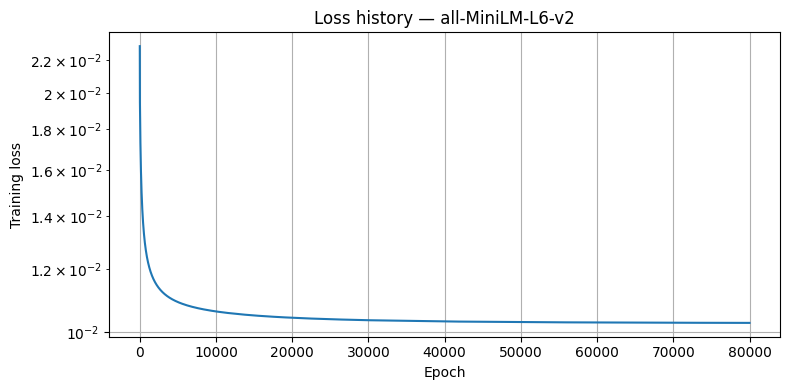

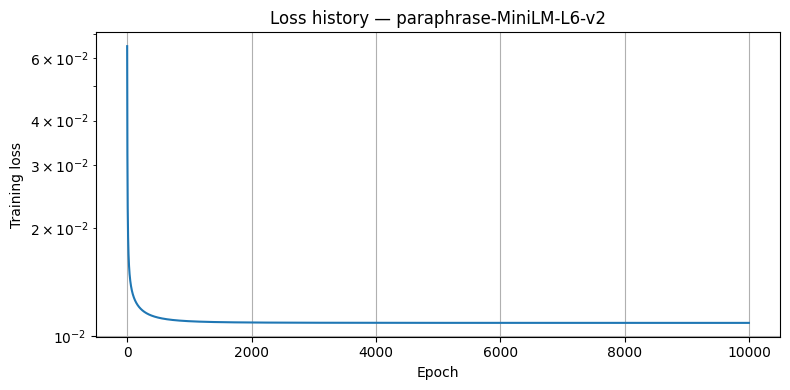

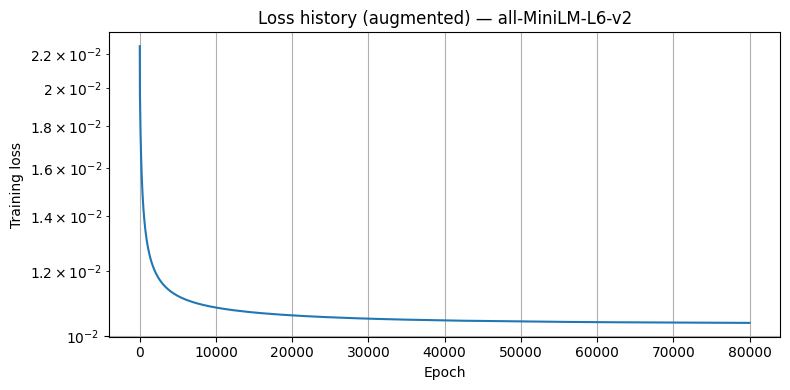

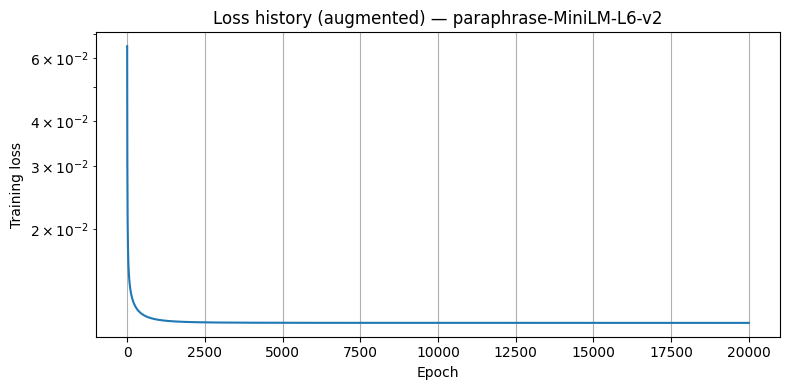

In [32]:
# Plot training loss history (log scale) for each embedding model
loss_dir = Path("new_matrices")
loss_dir.mkdir(parents=True, exist_ok=True)

for model_name in embedding_models:
    loss_history = artifacts[model_name]["loss_history"]
    plt.figure(figsize=(8, 4))
    plt.plot(np.arange(len(loss_history)), loss_history)
    plt.yscale("log")
    plt.xlabel("Epoch")
    plt.ylabel("Training loss")
    plt.title(f"Loss history — {model_name}")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(loss_dir / f"baseline_{model_name}_loss.png", dpi=200, bbox_inches="tight")
    plt.show()

if "artifacts_augmented" in globals():
    for model_name in embedding_models:
        loss_history = artifacts_augmented[model_name]["loss_history"]
        plt.figure(figsize=(8, 4))
        plt.plot(np.arange(len(loss_history)), loss_history)
        plt.yscale("log")
        plt.xlabel("Epoch")
        plt.ylabel("Training loss")
        plt.title(f"Loss history (augmented) — {model_name}")
        plt.grid(True)
        plt.tight_layout()
        plt.savefig(loss_dir / f"augmented_{model_name}_loss.png", dpi=200, bbox_inches="tight")
        plt.show()


## Step 5: Baseline head-to-head comparison

Now that both embedding models have been trained using the same linear PyTorch classifier pipeline, we compare them in several ways:

- overall metrics on train / test
- fine-label confusion matrices
- per-class F1 differences
- disagreement examples on the same test questions

This lets us separate **overall performance** from **where each embedding succeeds or fails**.



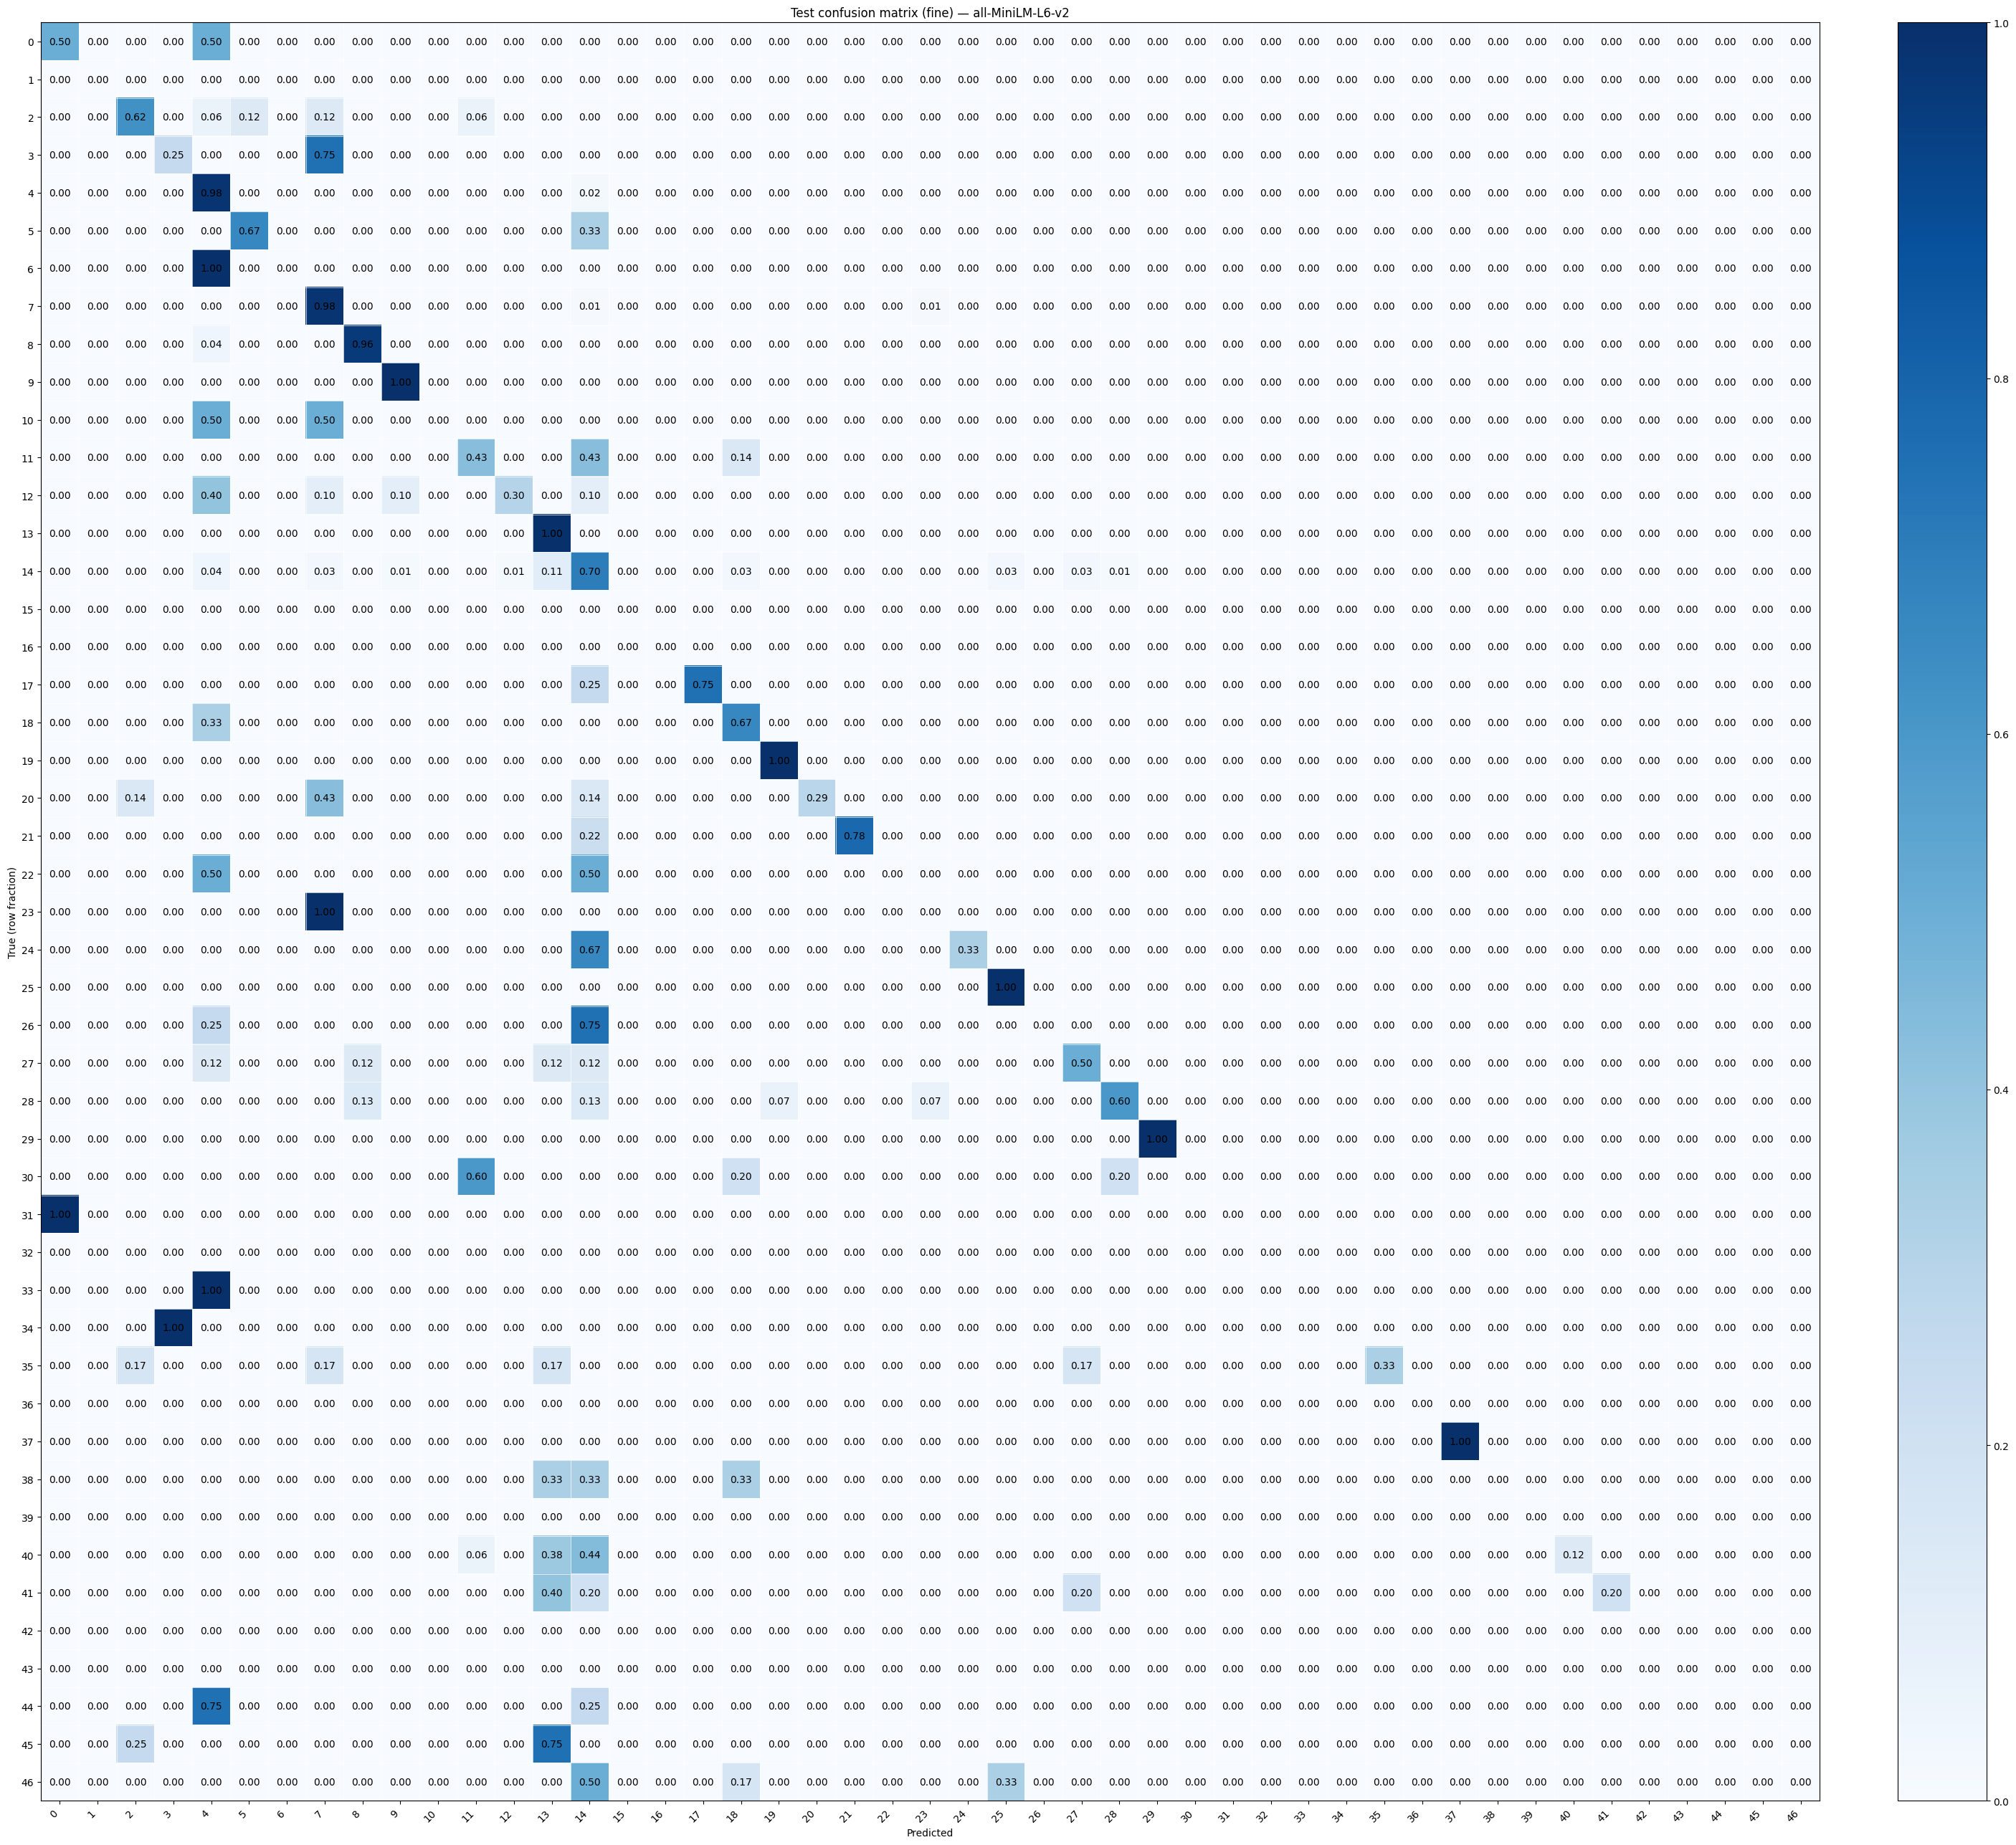

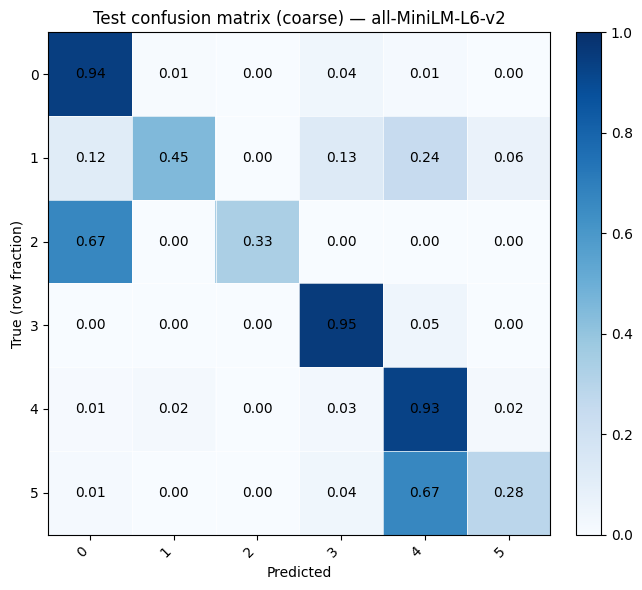

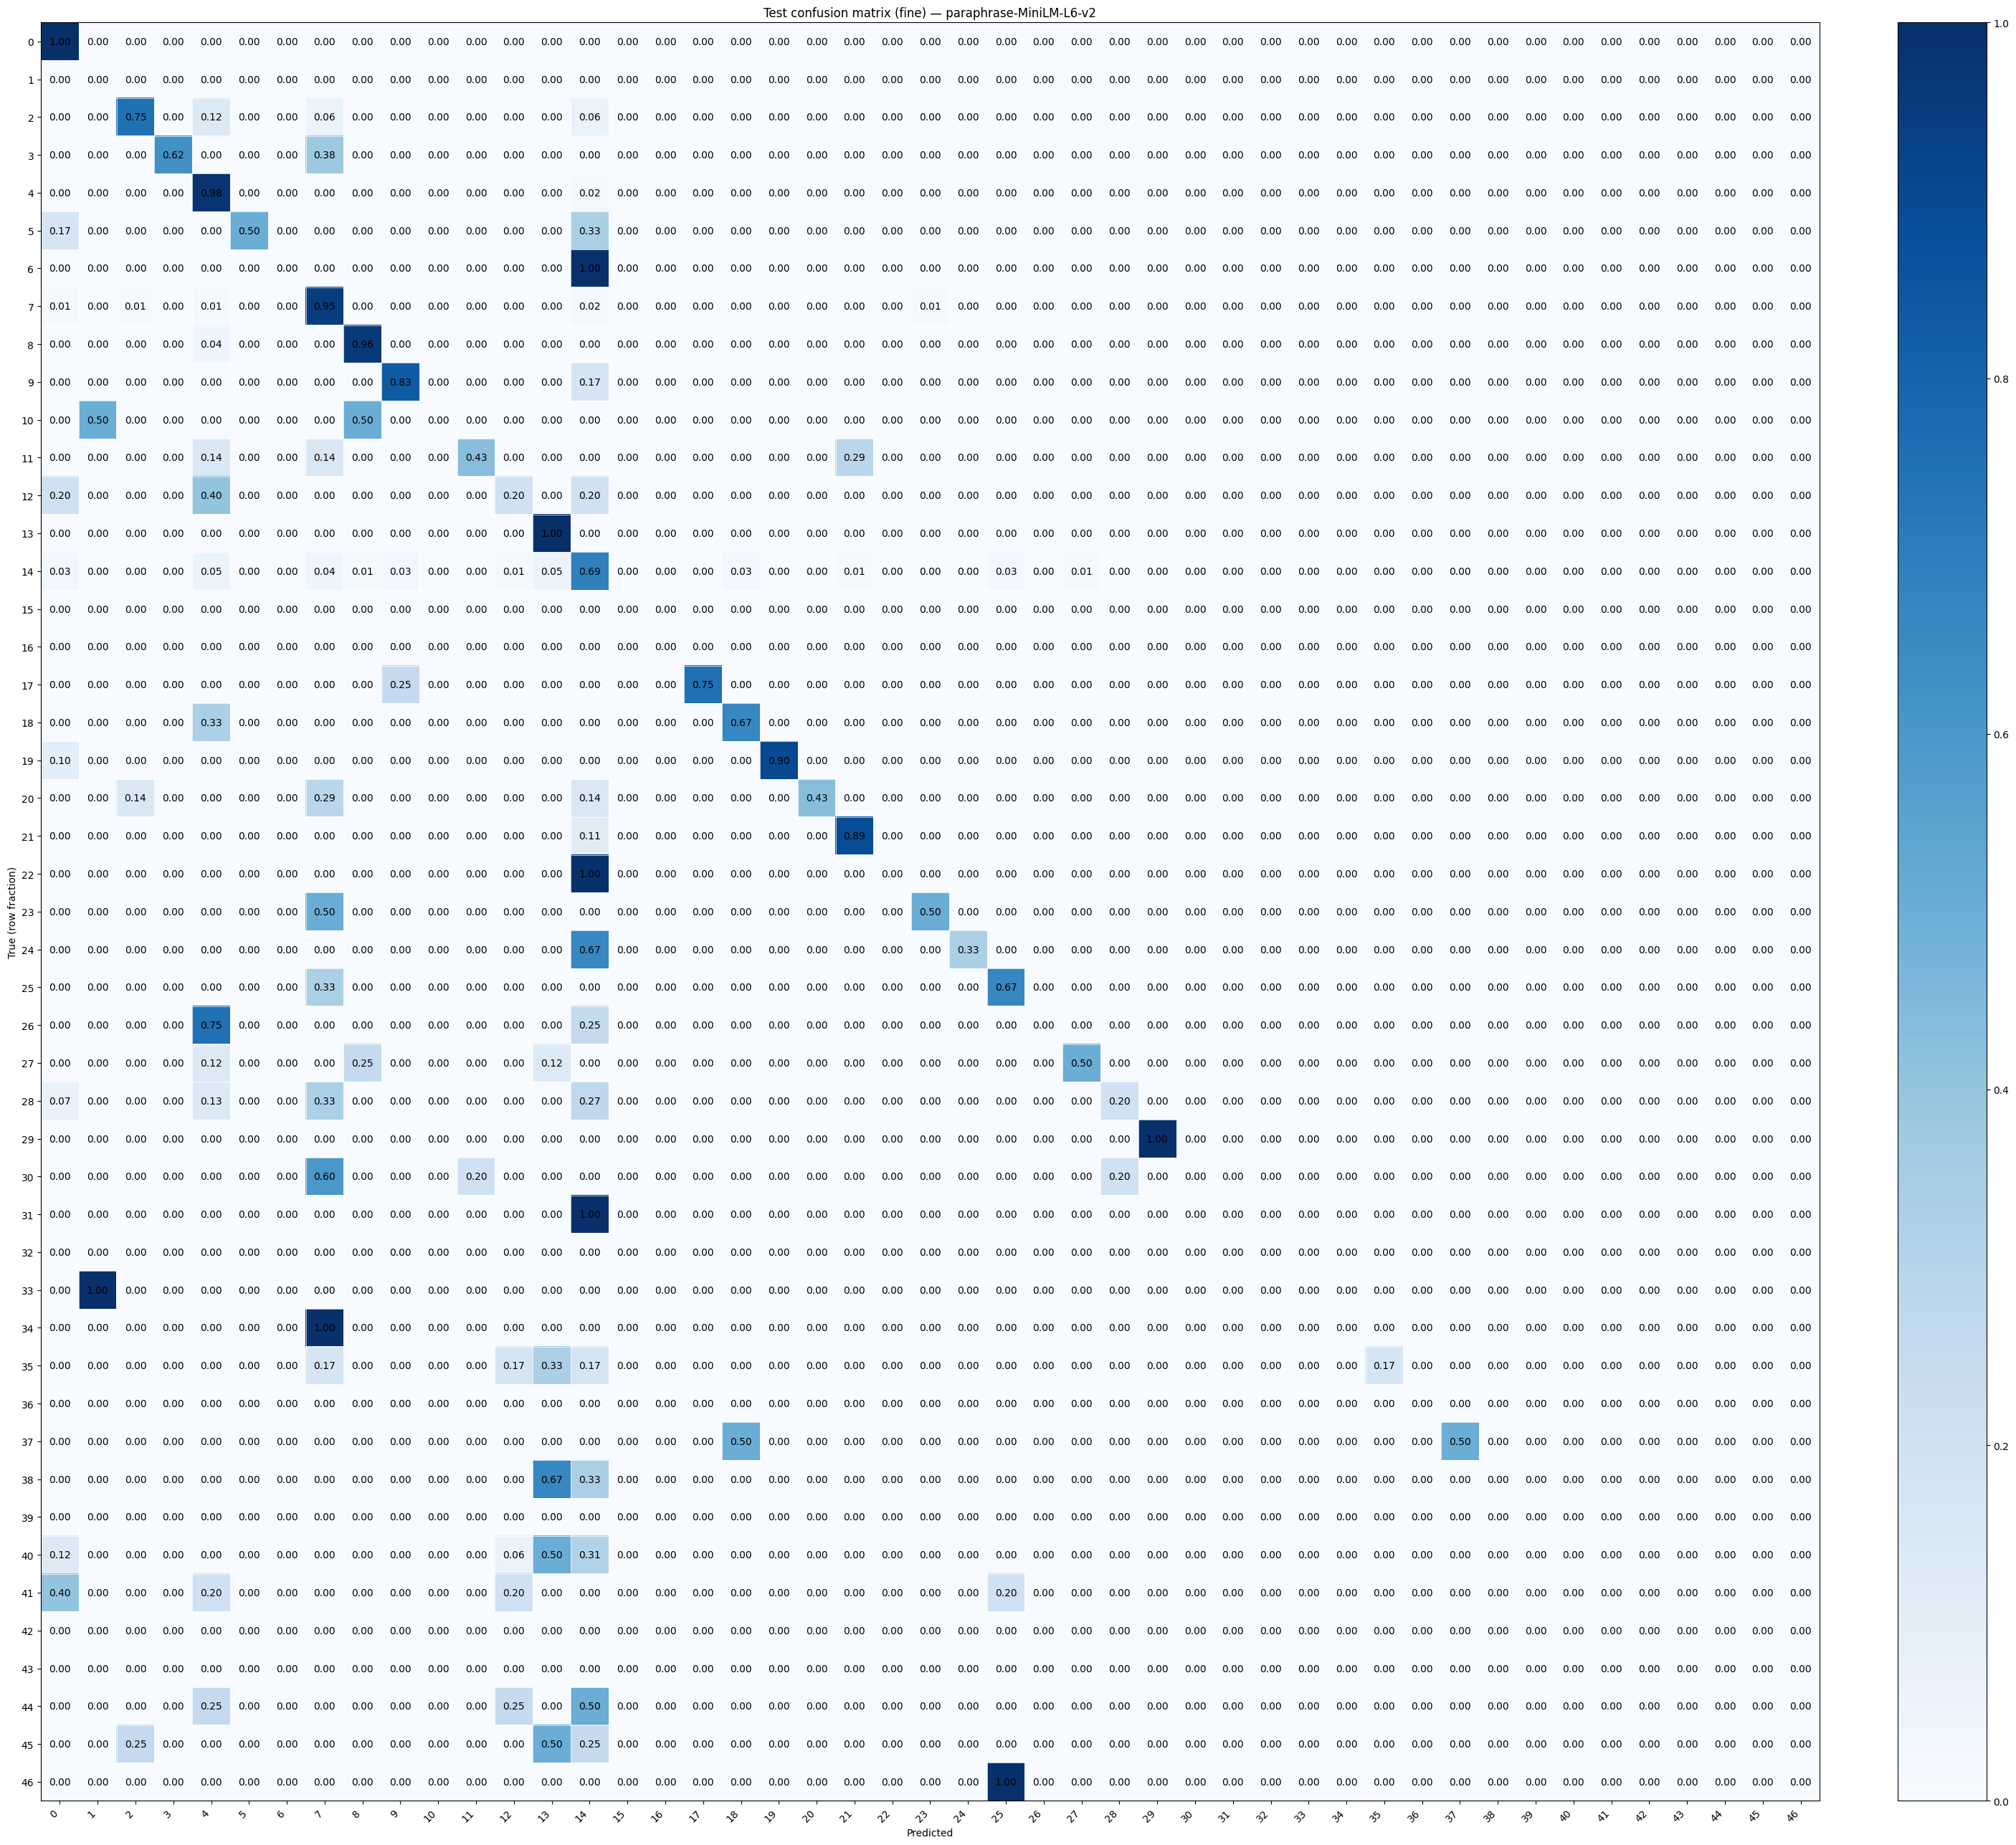

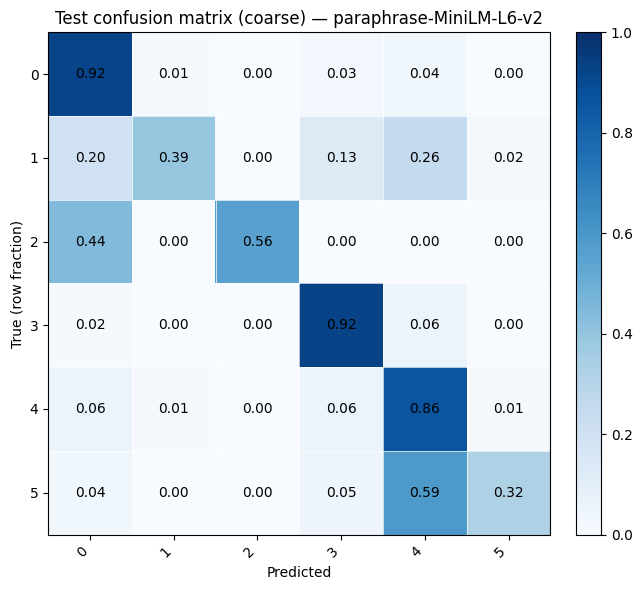

In [33]:
matrices_dir = Path("matrices")

for model_name in embedding_models:
    plot_conf_mat(
        artifacts[model_name]["y_test_idx"],
        artifacts[model_name]["test_pred_idx"],
        labels=np.arange(len(class_names)),
        title=f"Test confusion matrix (fine) — {model_name}",
        save_path=matrices_dir / f"baseline_{model_name}_fine.png"
    )

    # coarse view: map predicted fine label -> coarse label
    test_pred_coarse = pd.Series(artifacts[model_name]["test_pred_labels"]).map(fine_to_coarse).to_numpy()

    plot_conf_mat(
        y_test_coarse,
        test_pred_coarse,
        labels=class_names_coarse,
        title=f"Test confusion matrix (coarse) — {model_name}",
        save_path=matrices_dir / f"baseline_{model_name}_coarse.png"
    )

In [34]:
# Download All matrices
from pathlib import Path
import shutil

src_dir = Path('matrices')
dst_dir = Path('new_matrices')
dst_dir.mkdir(parents=True, exist_ok=True)

# newCodeBase writes baseline_{model}_fine/coarse.png -> 4 files total
patterns = ["baseline_*_fine.png", "baseline_*_coarse.png"]
copied = 0
for pattern in patterns:
    for img_path in src_dir.glob(pattern):
        shutil.copy2(img_path, dst_dir / img_path.name)
        copied += 1

print(f'Copied {copied} files to {dst_dir}')


Copied 4 files to new_matrices


In [35]:
# Combine the 4 matrices into a single PDF
from pathlib import Path
from PIL import Image

src_dir = Path('new_matrices')
pdf_path = src_dir / 'combined_matrices.pdf'

image_paths = sorted(src_dir.glob('baseline_*_*.png'))
if not image_paths:
    raise FileNotFoundError('No matrices found in new_matrices')

images = [Image.open(p).convert('RGB') for p in image_paths]
images[0].save(pdf_path, save_all=True, append_images=images[1:])

print(f'Wrote {pdf_path} with {len(images)} pages')


Wrote new_matrices/combined_matrices.pdf with 9 pages


In [36]:
# Compare accuracy scores for each model on fine and coarse labels
accuracy_rows = []
for model_name in embedding_models:
    fine_acc = accuracy_score(
        artifacts[model_name]["y_test_idx"],
        artifacts[model_name]["test_pred_idx"]
    )
    test_pred_coarse = pd.Series(artifacts[model_name]["test_pred_labels"]).map(fine_to_coarse).to_numpy()
    coarse_acc = accuracy_score(y_test_coarse, test_pred_coarse)
    accuracy_rows.append({
        "model": model_name,
        "fine_accuracy": fine_acc,
        "coarse_accuracy": coarse_acc,
    })

accuracy_df = pd.DataFrame(accuracy_rows).sort_values("fine_accuracy", ascending=False)
accuracy_df


,model,fine_accuracy,coarse_accuracy
0,all-MiniLM-L6-v2,0.732,0.730
1,paraphrase-MiniLM-L6-v2,0.710,0.704


## Step 9: Add targeted holdout samples back into training

We upsample the coarse labels 1, 2, and 5 by moving 10% of each class
from the holdout set into the training set. This keeps the test set unchanged
and reduces the holdout size accordingly.


In [48]:
# Add 30% more samples (per coarse label) from holdout into training.
desired_increase_percentage = 0.8
target_coarse_labels = [2]
train_coarse_counts = train_split_df["label-coarse"].value_counts()

added_rows = []
for coarse_label in target_coarse_labels:
    desired_increase = int(np.ceil(train_coarse_counts.get(coarse_label, 0) * desired_increase_percentage))
    if desired_increase <= 0:
        continue
    candidates = holdout_split_df[holdout_split_df["label-coarse"] == coarse_label]
    take_n = min(desired_increase, len(candidates))
    if take_n == 0:
        continue
    added_rows.append(candidates.sample(n=take_n, random_state=RANDOM_STATE))

if added_rows:
    added_df = pd.concat(added_rows)
else:
    added_df = holdout_split_df.head(0).copy()

train_split_df = pd.concat([train_split_df, added_df], ignore_index=True).reset_index(drop=True)
holdout_split_df = holdout_split_df.drop(added_df.index).reset_index(drop=True)

print("Added rows by coarse label:")
display(added_df["label-coarse"].value_counts().sort_index())

print("\nUpdated train coarse-label distribution:")
display(train_split_df["label-coarse"].value_counts().sort_index())

print("\nUpdated holdout coarse-label distribution:")
display(holdout_split_df["label-coarse"].value_counts().sort_index())


Added rows by coarse label:


Series([], Name: count, dtype: int64)


Updated train coarse-label distribution:


label-coarse
0    1049
1    1250
2      86
3    1098
4     806
5     835
Name: count, dtype: int64


Updated holdout coarse-label distribution:


label-coarse
0    113
3    125
4     90
Name: count, dtype: int64

## Step 10: Retrain after holdout augmentation

We retrain the embedding + linear model pipeline using the updated training set
and re-evaluate on the original test set.


In [49]:
X_train_text = train_split_df["text"].tolist()
y_train_labels = train_split_df["label-fine"].to_numpy()

artifacts_augmented = {}

for model_name in embedding_models:
    epochs = 10000 if model_name == "paraphrase-MiniLM-L6-v2" else 80000
    run_artifacts = train_one_embedding_pipeline(
        model_name=model_name,
        X_train_text=X_train_text,
        X_test_text=X_test_text,
        y_train_labels=y_train_labels,
        y_test_labels=y_test_labels,
        class_to_idx=class_to_idx,
        class_names=class_names,
        epochs=epochs,
        lr=7,
    )
    artifacts_augmented[model_name] = run_artifacts


===== Running all-MiniLM-L6-v2 =====


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 200/10000 - loss: 0.012112
Epoch 400/10000 - loss: 0.011490
Epoch 600/10000 - loss: 0.011261
Epoch 800/10000 - loss: 0.011152
Epoch 1000/10000 - loss: 0.011092
Epoch 1200/10000 - loss: 0.011056
Epoch 1400/10000 - loss: 0.011033
Epoch 1600/10000 - loss: 0.011018
Epoch 1800/10000 - loss: 0.011008
Epoch 2000/10000 - loss: 0.011001
Epoch 2200/10000 - loss: 0.010995
Epoch 2400/10000 - loss: 0.010991
Epoch 2600/10000 - loss: 0.010988
Epoch 2800/10000 - loss: 0.010986
Epoch 3000/10000 - loss: 0.010984
Epoch 3200/10000 - loss: 0.010982
Epoch 3400/10000 - loss: 0.010981
Epoch 3600/10000 - loss: 0.010980
Epoch 3800/10000 - loss: 0.010979
Epoch 4000/10000 - loss: 0.010979
Epoch 4200/10000 - loss: 0.010978
Epoch 4400/10000 - loss: 0.010978
Epoch 4600/10000 - loss: 0.010977
Epoch 4800/10000 - loss: 0.010977
Epoch 5000/10000 - loss: 0.010976
Epoch 5200/10000 - loss: 0.010976
Epoch 5400/10000 - loss: 0.010976
Epoch 5600/10000 - loss: 0.010976
Epoch 5800/10000 - loss: 0.010975
Epoch 6000/10000 -

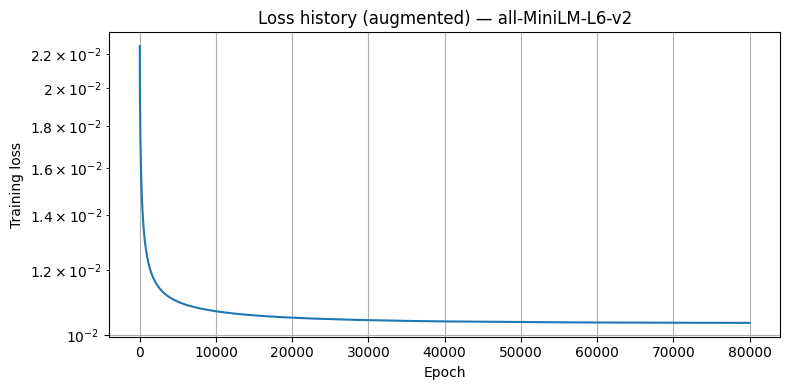

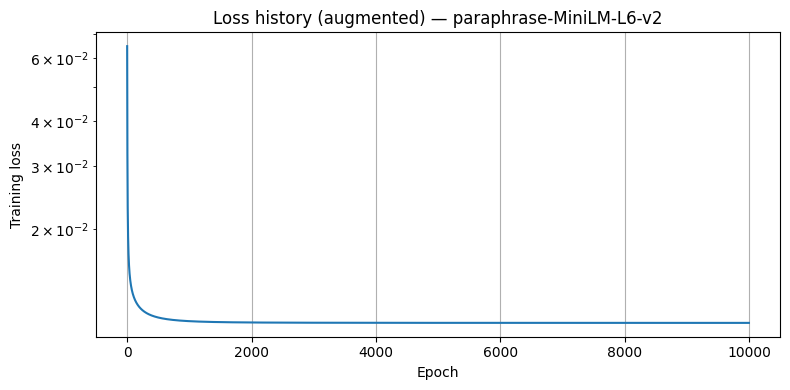

In [39]:
# Plot training loss history (log scale) for augmented models
loss_dir = Path("new_matrices")
loss_dir.mkdir(parents=True, exist_ok=True)

for model_name in embedding_models:
    loss_history = artifacts_augmented[model_name]["loss_history"]
    plt.figure(figsize=(8, 4))
    plt.plot(np.arange(len(loss_history)), loss_history)
    plt.yscale("log")
    plt.xlabel("Epoch")
    plt.ylabel("Training loss")
    plt.title(f"Loss history (augmented) — {model_name}")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(loss_dir / f"augmented_{model_name}_loss.png", dpi=200, bbox_inches="tight")
    plt.show()


## Step 11: Confusion matrices after holdout augmentation

We visualize fine and coarse confusion matrices for the retrained models.


In [50]:
# Recompute accuracy after augmentation
accuracy_rows = []
for model_name in embedding_models:
    fine_acc = accuracy_score(
        artifacts_augmented[model_name]["y_test_idx"],
        artifacts_augmented[model_name]["test_pred_idx"]
    )
    test_pred_coarse = pd.Series(artifacts_augmented[model_name]["test_pred_labels"]).map(fine_to_coarse).to_numpy()
    coarse_acc = accuracy_score(y_test_coarse, test_pred_coarse)
    accuracy_rows.append({
        "model": model_name,
        "fine_accuracy": fine_acc,
        "coarse_accuracy": coarse_acc,
    })

accuracy_df_augmented = pd.DataFrame(accuracy_rows).sort_values("fine_accuracy", ascending=False)
accuracy_df_augmented

,model,fine_accuracy,coarse_accuracy
0,all-MiniLM-L6-v2,0.740,0.746
1,paraphrase-MiniLM-L6-v2,0.718,0.718


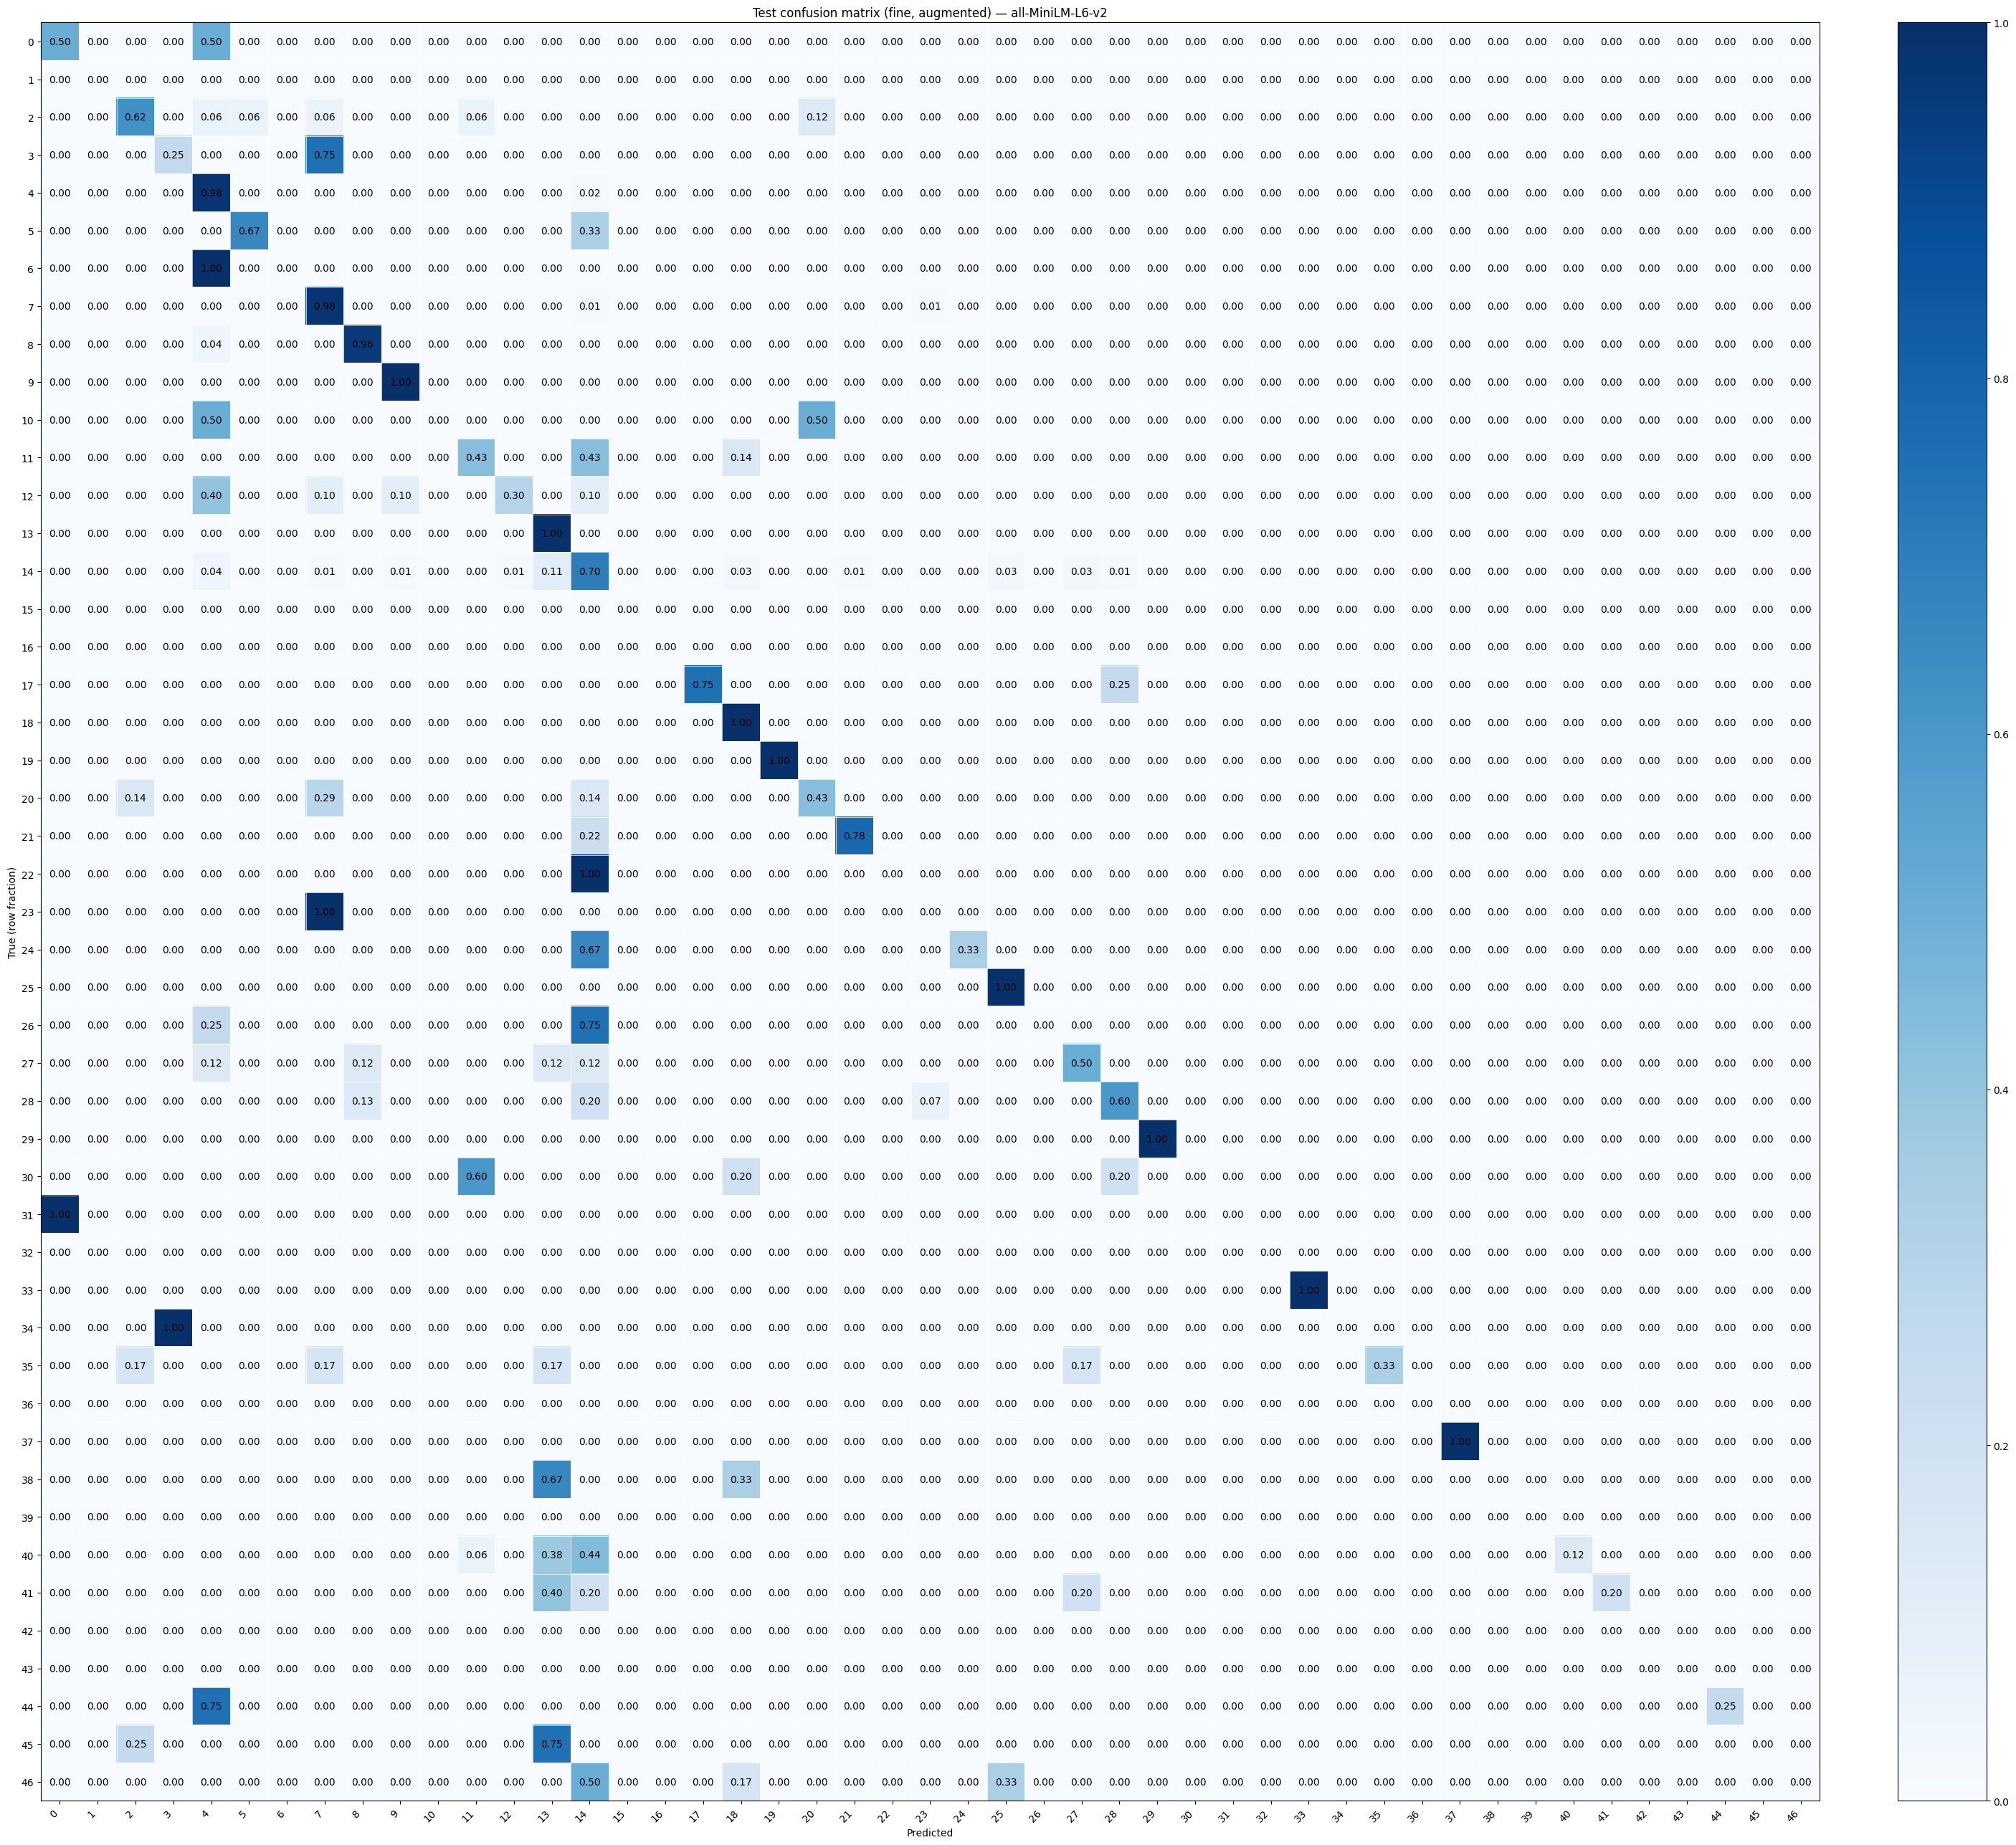

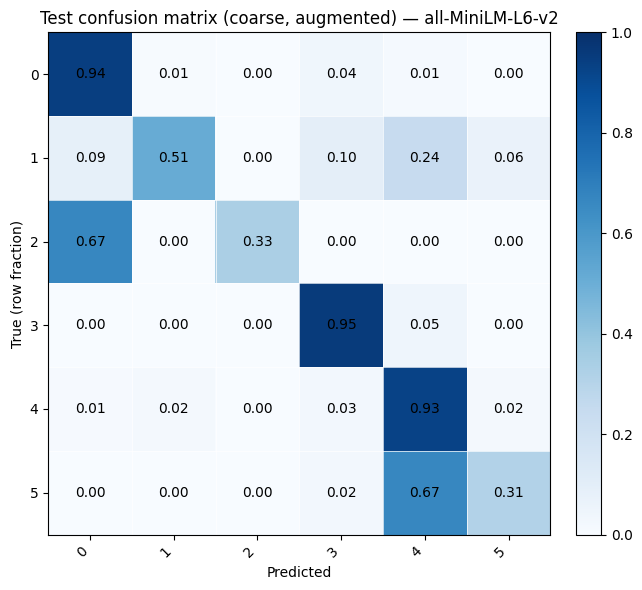

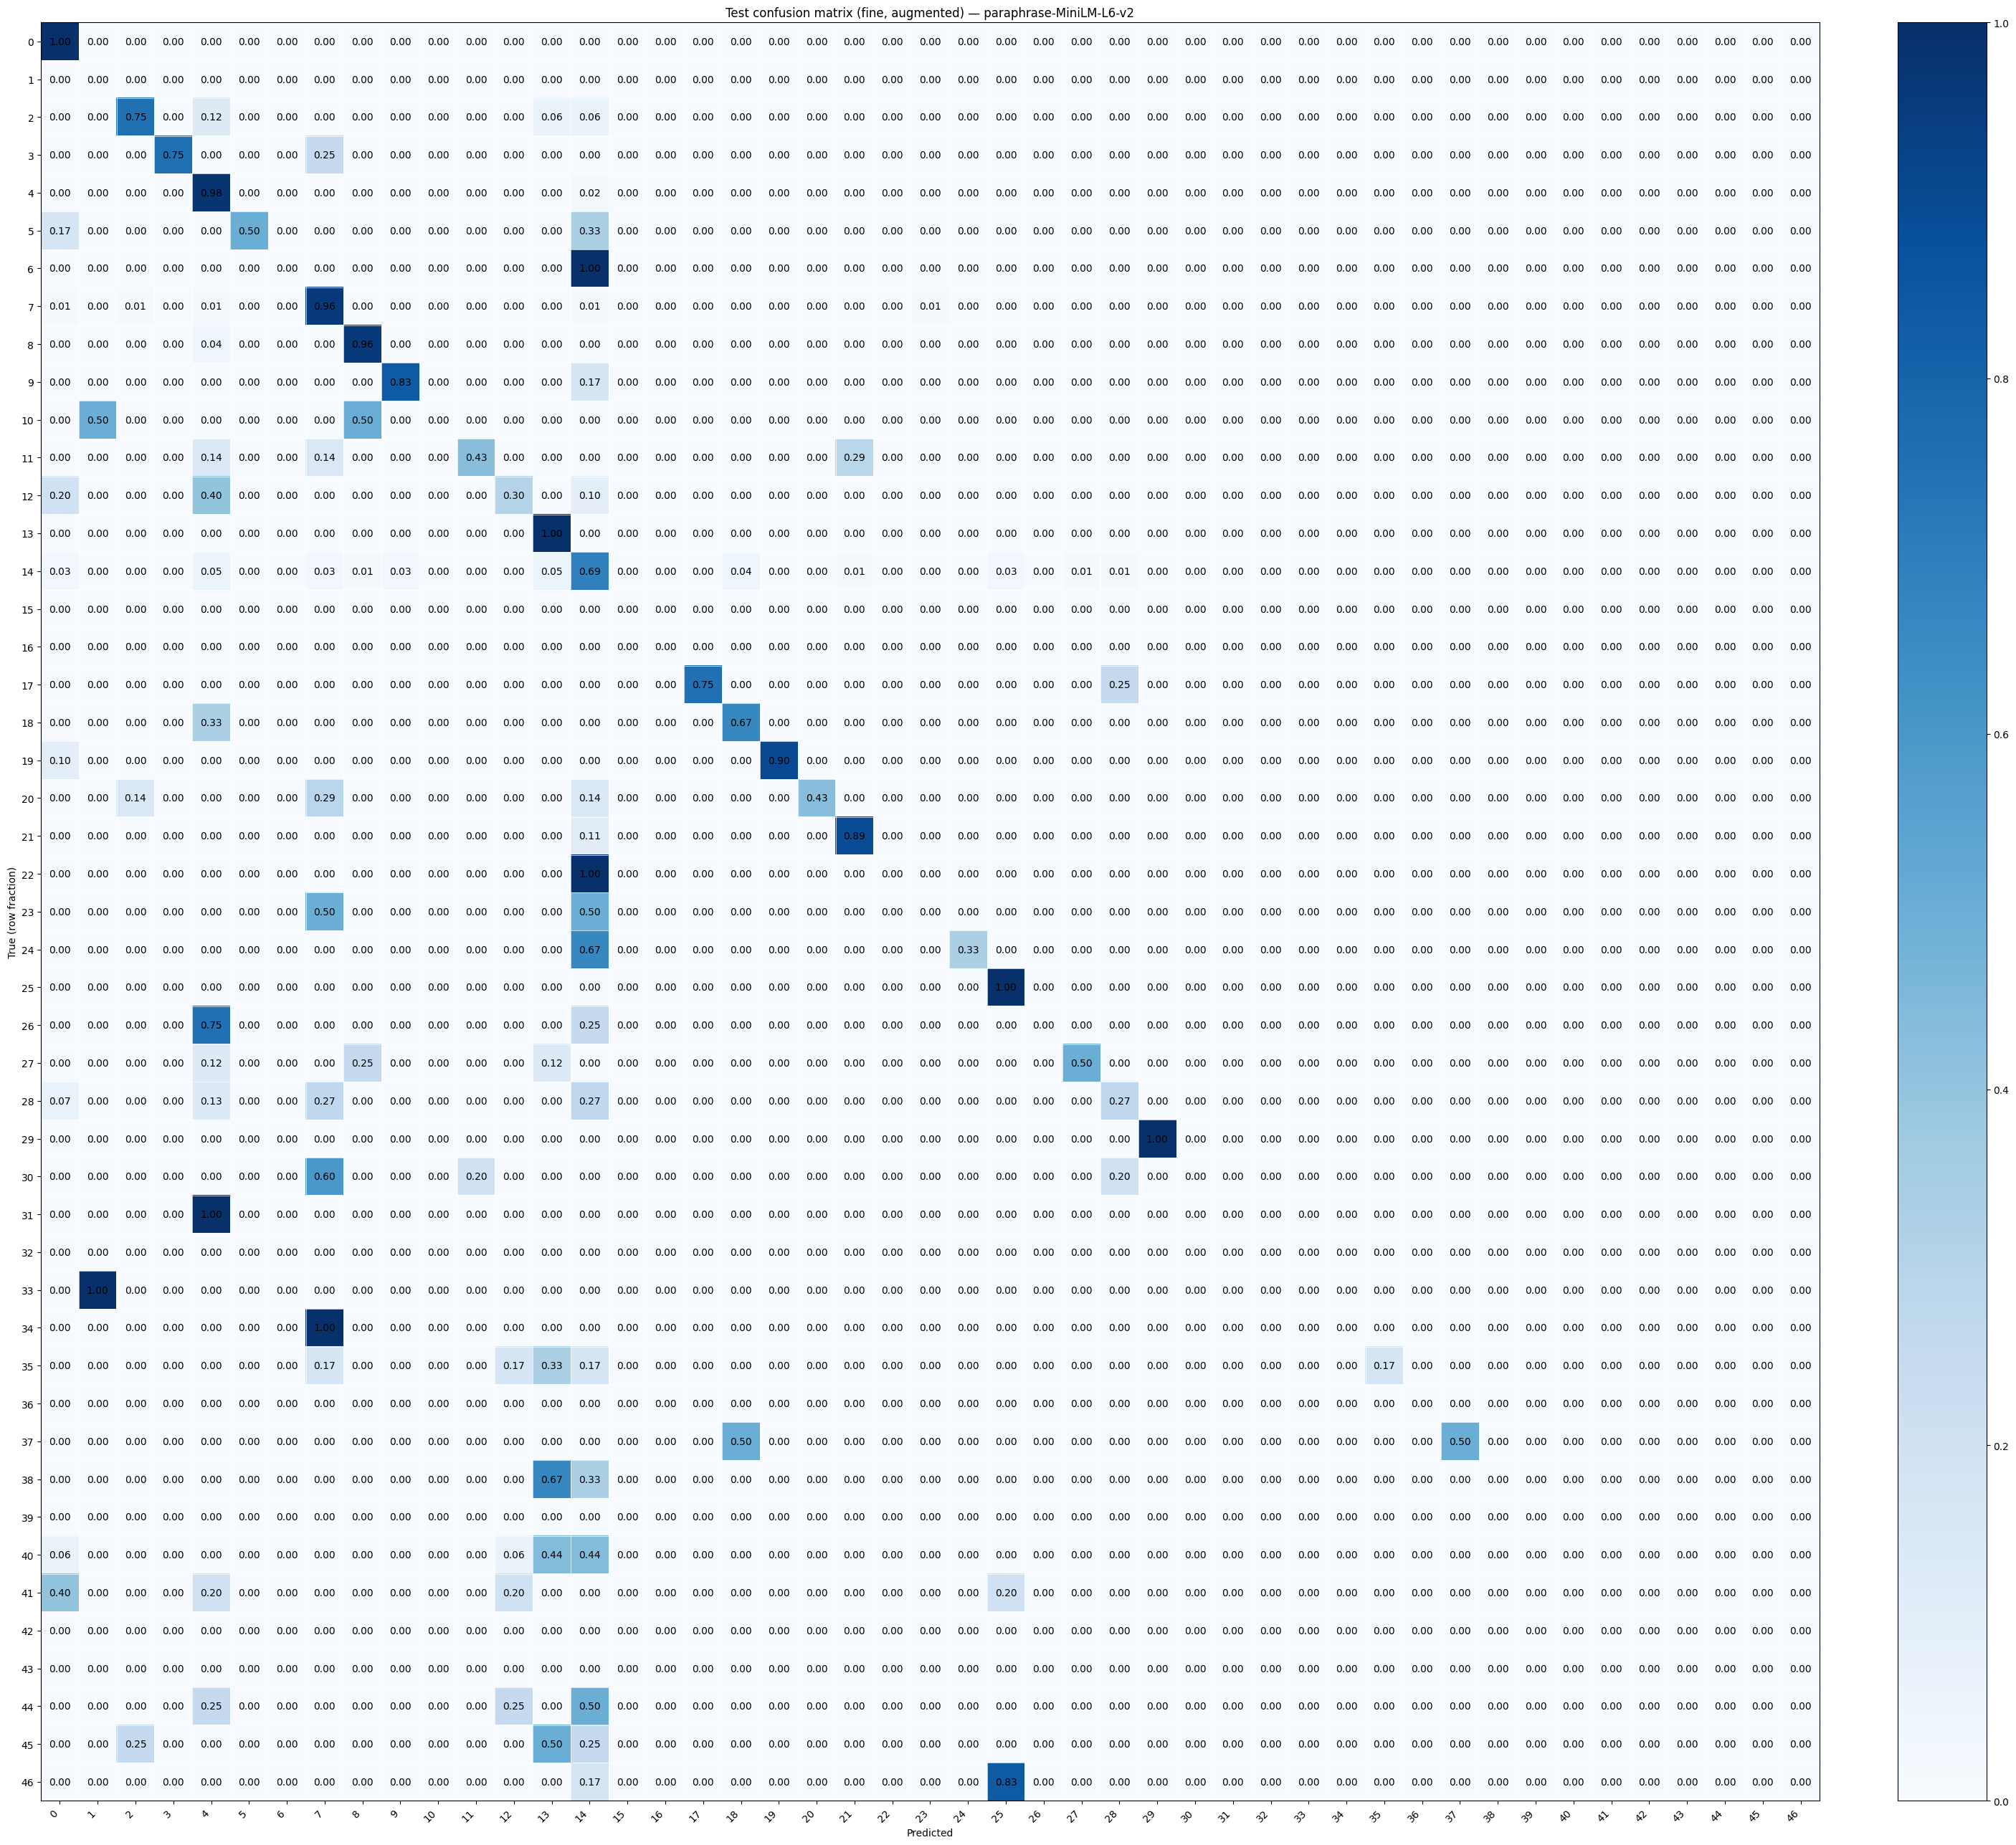

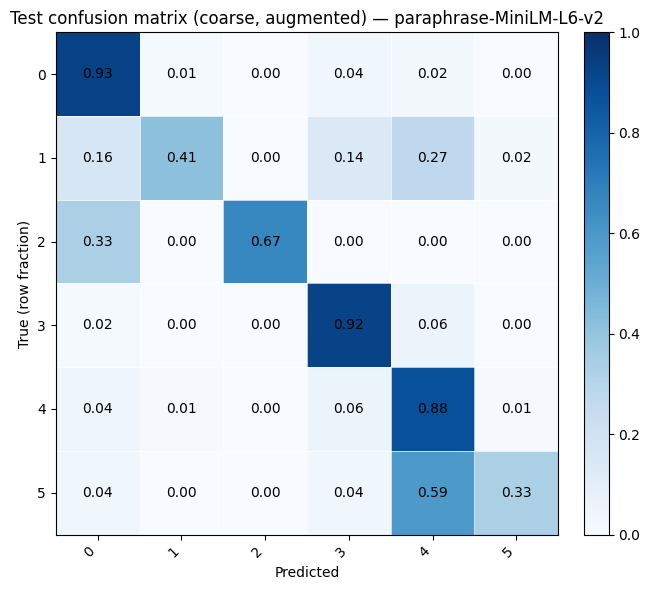

In [51]:
matrices_dir = Path("new_matrices")
matrices_dir.mkdir(parents=True, exist_ok=True)

for model_name in embedding_models:
    plot_conf_mat(
        artifacts_augmented[model_name]["y_test_idx"],
        artifacts_augmented[model_name]["test_pred_idx"],
        labels=np.arange(len(class_names)),
        title=f"Test confusion matrix (fine, augmented) — {model_name}",
        save_path=matrices_dir / f"augmented_{model_name}_fine.png"
    )

    test_pred_coarse = pd.Series(artifacts_augmented[model_name]["test_pred_labels"]).map(fine_to_coarse).to_numpy()

    plot_conf_mat(
        y_test_coarse,
        test_pred_coarse,
        labels=class_names_coarse,
        title=f"Test confusion matrix (coarse, augmented) — {model_name}",
        save_path=matrices_dir / f"augmented_{model_name}_coarse.png"
    )


Subset fine labels: [7, 18, 28, 34, 38, 39]


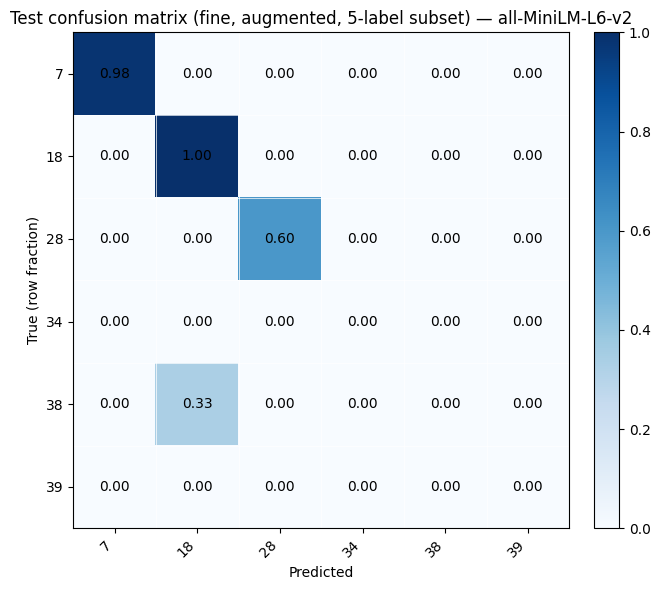

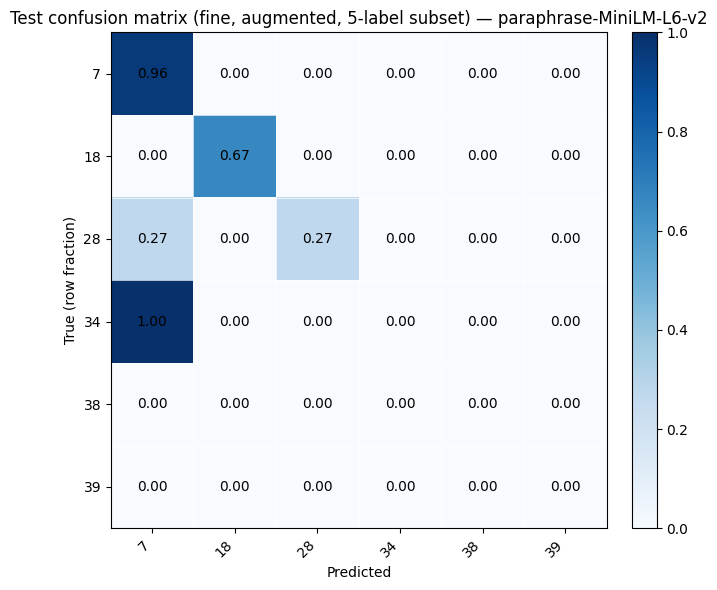

In [52]:
# Random 5-label fine confusion matrices (augmented)
if "rng" not in globals():
    rng = np.random.default_rng(RANDOM_STATE)
subset_labels = rng.choice(class_names, size=6, replace=False).tolist()
subset_labels = sorted(subset_labels)
print("Subset fine labels:", subset_labels)

subset_indices = [class_to_idx[label] for label in subset_labels]

for model_name in embedding_models:
    y_true_labels = np.asarray(y_test_labels)
    test_pred_idx = artifacts_augmented[model_name]["test_pred_idx"]
    y_pred_labels = np.take(class_names, test_pred_idx)

    cm_full = confusion_matrix(
        y_true_labels,
        y_pred_labels,
        labels=class_names,
        normalize="true",
    )
    cm_subset = cm_full[np.ix_(subset_indices, subset_indices)]

    plot_conf_mat(
        y_true_labels,
        y_pred_labels,
        labels=subset_labels,
        title=f"Test confusion matrix (fine, augmented, 5-label subset) — {model_name}",
        save_path=Path("new_matrices") / f"augmented_{model_name}_fine_subset5.png",
        cm_override=cm_subset,
    )


In [43]:
# Copy confusion matrices into new_matrices
from pathlib import Path
import shutil

src_dir = Path("matrices")
dst_dir = Path("new_matrices")
dst_dir.mkdir(parents=True, exist_ok=True)

copied = 0
for img_path in src_dir.glob("*.png"):
    shutil.copy2(img_path, dst_dir / img_path.name)
    copied += 1

print(f"Copied {copied} files to {dst_dir}")


Copied 12 files to new_matrices


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 200/10000 - loss: 0.016740
Epoch 400/10000 - loss: 0.015169
Epoch 600/10000 - loss: 0.014288
Epoch 800/10000 - loss: 0.013711
Epoch 1000/10000 - loss: 0.013300
Epoch 1200/10000 - loss: 0.012990
Epoch 1400/10000 - loss: 0.012746
Epoch 1600/10000 - loss: 0.012549
Epoch 1800/10000 - loss: 0.012386
Epoch 2000/10000 - loss: 0.012248
Epoch 2200/10000 - loss: 0.012129
Epoch 2400/10000 - loss: 0.012027
Epoch 2600/10000 - loss: 0.011936
Epoch 2800/10000 - loss: 0.011856
Epoch 3000/10000 - loss: 0.011785
Epoch 3200/10000 - loss: 0.011721
Epoch 3400/10000 - loss: 0.011662
Epoch 3600/10000 - loss: 0.011609
Epoch 3800/10000 - loss: 0.011561
Epoch 4000/10000 - loss: 0.011517
Epoch 4200/10000 - loss: 0.011476
Epoch 4400/10000 - loss: 0.011438
Epoch 4600/10000 - loss: 0.011402
Epoch 4800/10000 - loss: 0.011370
Epoch 5000/10000 - loss: 0.011339
Epoch 5200/10000 - loss: 0.011310
Epoch 5400/10000 - loss: 0.011283
Epoch 5600/10000 - loss: 0.011258
Epoch 5800/10000 - loss: 0.011234
Epoch 6000/10000 -

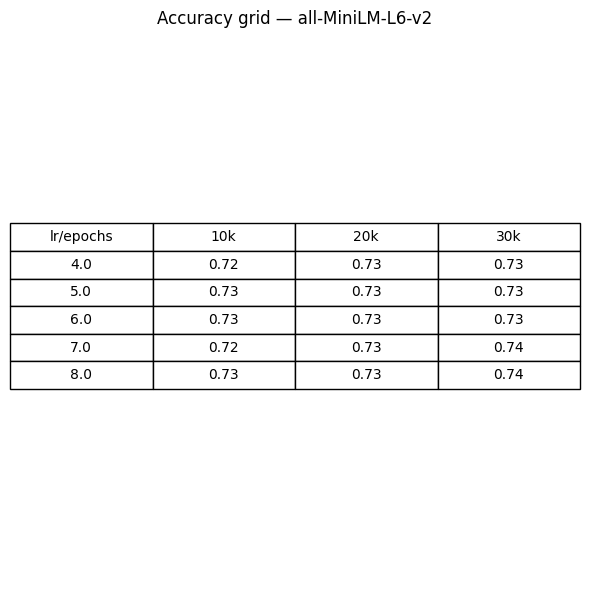

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 200/10000 - loss: 0.012835
Epoch 400/10000 - loss: 0.011959
Epoch 600/10000 - loss: 0.011596
Epoch 800/10000 - loss: 0.011400
Epoch 1000/10000 - loss: 0.011282
Epoch 1200/10000 - loss: 0.011204
Epoch 1400/10000 - loss: 0.011151
Epoch 1600/10000 - loss: 0.011113
Epoch 1800/10000 - loss: 0.011085
Epoch 2000/10000 - loss: 0.011065
Epoch 2200/10000 - loss: 0.011049
Epoch 2400/10000 - loss: 0.011036
Epoch 2600/10000 - loss: 0.011027
Epoch 2800/10000 - loss: 0.011019
Epoch 3000/10000 - loss: 0.011013
Epoch 3200/10000 - loss: 0.011007
Epoch 3400/10000 - loss: 0.011003
Epoch 3600/10000 - loss: 0.011000
Epoch 3800/10000 - loss: 0.010997
Epoch 4000/10000 - loss: 0.010994
Epoch 4200/10000 - loss: 0.010992
Epoch 4400/10000 - loss: 0.010990
Epoch 4600/10000 - loss: 0.010988
Epoch 4800/10000 - loss: 0.010987
Epoch 5000/10000 - loss: 0.010986
Epoch 5200/10000 - loss: 0.010985
Epoch 5400/10000 - loss: 0.010984
Epoch 5600/10000 - loss: 0.010983
Epoch 5800/10000 - loss: 0.010982
Epoch 6000/10000 -

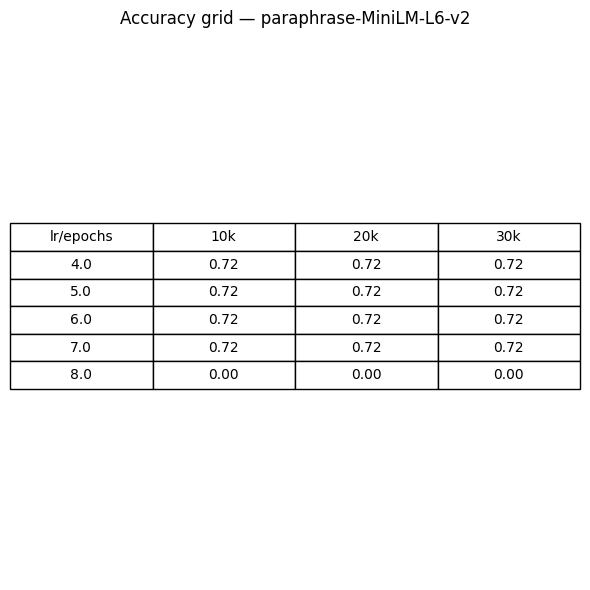

In [44]:
# Learning rate vs epoch accuracy grids (per model)
lr_values = [4,5,6,7,8]
epoch_values = [10000, 20000, 30000]

# Note: this trains len(lr_values) * len(epoch_values) models per embedding model.
def compute_accuracy_grid_for_model(
    model_name,
    X_train_text,
    X_test_text,
    y_train_labels,
    y_test_labels,
    class_to_idx,
    class_names,
    lr_values,
    epoch_values,
):
    X_train_emb = embed_texts(model_name, X_train_text)
    X_test_emb = embed_texts(model_name, X_test_text)

    X_train_tensor, Y_train_onehot_tensor, _ = make_multiclass_tensors(
        X_train_emb,
        y_train_labels,
        class_to_idx,
    )
    X_test_tensor, _, y_test_idx = make_multiclass_tensors(
        X_test_emb,
        y_test_labels,
        class_to_idx,
    )

    input_dim = X_train_tensor.shape[1]
    output_dim = Y_train_onehot_tensor.shape[1]

    acc_grid = np.zeros((len(lr_values), len(epoch_values)), dtype=float)

    for i, lr in enumerate(lr_values):
        for j, epochs in enumerate(epoch_values):
            model = build_linear_multiclass_model(input_dim, output_dim)
            trained_model, _ = model_fit_pytorch(
                X_train_tensor,
                Y_train_onehot_tensor,
                model,
                epochs=epochs,
                lr=lr,
            )
            _, pred_idx = pytorch_model_multiclass_inference(trained_model, X_test_tensor)
            acc_grid[i, j] = accuracy_score(y_test_idx, pred_idx)

    return acc_grid


def plot_accuracy_grid_table(acc_grid, lr_values, epoch_values, title, save_path=None):
    epoch_labels = [f"{e // 1000}k" for e in epoch_values]
    cell_text = [["lr/epochs"] + epoch_labels]
    for lr, row in zip(lr_values, acc_grid):
        cell_text.append([f"{lr:.1f}"] + [f"{acc:.2f}" for acc in row])

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.axis("off")
    table = ax.table(cellText=cell_text, cellLoc="center", loc="center")
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.4)
    ax.set_title(title)
    fig.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=200, bbox_inches="tight")

    plt.show()


for model_name in embedding_models:
    acc_grid = compute_accuracy_grid_for_model(
        model_name,
        X_train_text,
        X_test_text,
        y_train_labels,
        y_test_labels,
        class_to_idx,
        class_names,
        lr_values,
        epoch_values,
    )

    plot_accuracy_grid_table(
        acc_grid,
        lr_values,
        epoch_values,
        title=f"Accuracy grid — {model_name}",
        save_path=Path("new_matrices") / f"lr_epoch_accuracy_{model_name}.png",
    )


In [45]:
# Copy lr/epoch grid images into new_matrices
from pathlib import Path
import shutil

src_dir = Path("new_matrices")
dst_dir = Path("new_matrices")
dst_dir.mkdir(parents=True, exist_ok=True)

copied = 0
skipped = 0
for img_path in src_dir.glob("lr_epoch_accuracy_*.png"):
    dest_path = dst_dir / img_path.name
    if img_path.resolve() == dest_path.resolve():
        skipped += 1
        continue
    shutil.copy2(img_path, dest_path)
    copied += 1

print(f"Copied {copied} grid files to {dst_dir} (skipped {skipped} already there)")


Copied 0 grid files to new_matrices (skipped 2 already there)


fine_top10 labels: [4, 14, 7, 13, 12, 0, 1, 8, 9, 5]


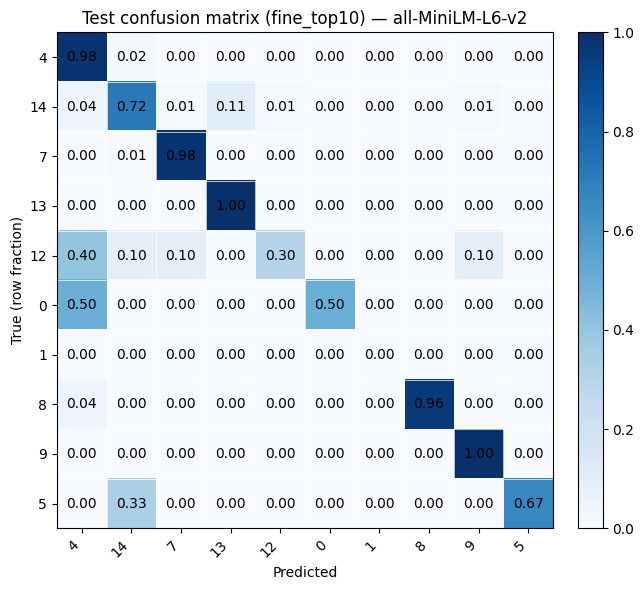

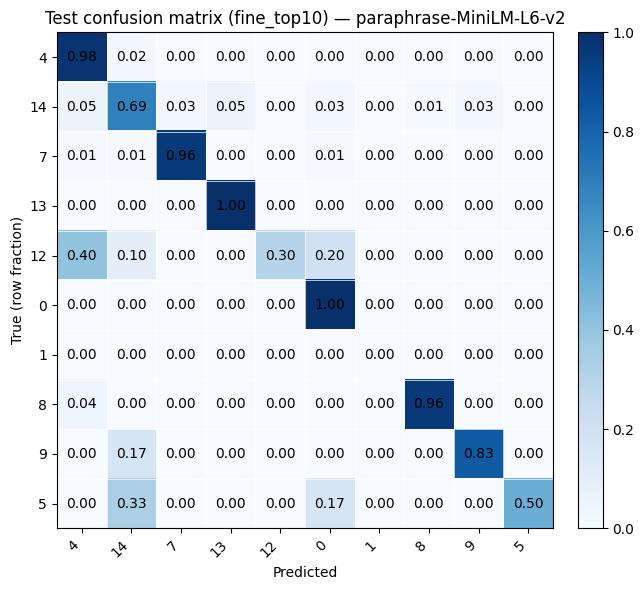

fine_bottom10 labels: [46, 16, 43, 41, 39, 35, 15, 45, 33, 42]


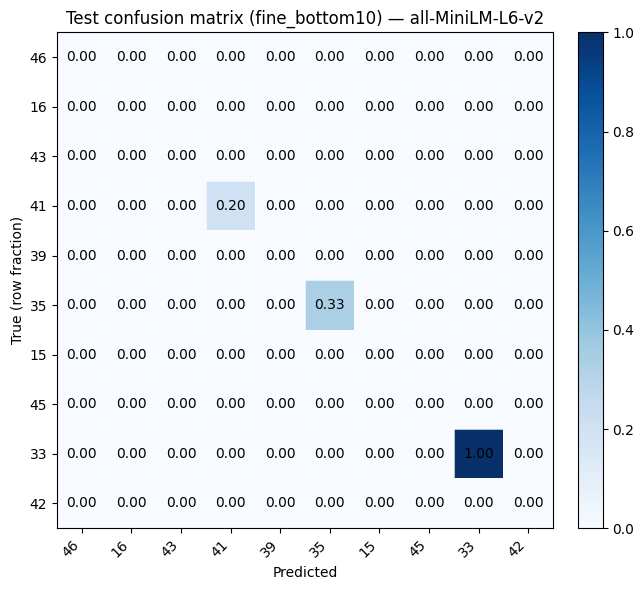

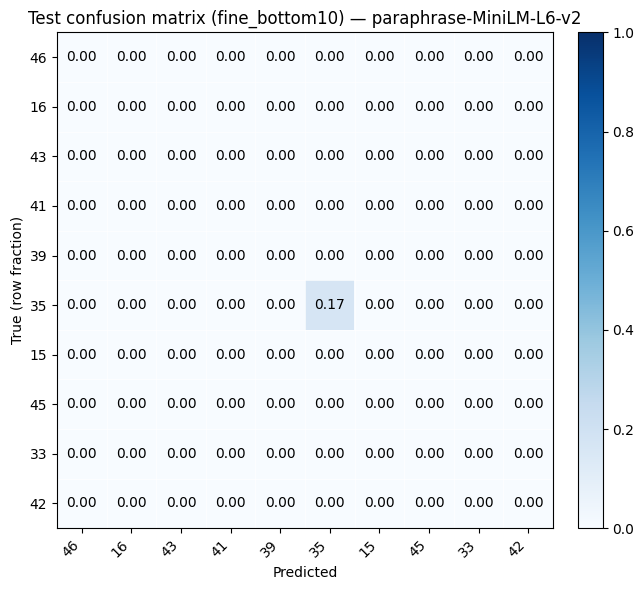

In [46]:
# Fine-label subset confusion matrices (top/bottom 10 by train frequency)
train_counts = train_split_df["label-fine"].value_counts()

top10_labels = train_counts.head(10).index.tolist()
bottom10_labels = train_counts.sort_values(ascending=True).head(10).index.tolist()

subset_groups = {
    "fine_top10": top10_labels,
    "fine_bottom10": bottom10_labels,
}

artifacts_source = artifacts_augmented if "artifacts_augmented" in globals() else artifacts

for subset_name, subset_labels in subset_groups.items():
    print(f"{subset_name} labels: {subset_labels}")
    subset_indices = [class_to_idx[label] for label in subset_labels]

    for model_name in embedding_models:
        y_true_labels = np.asarray(y_test_labels)
        test_pred_idx = artifacts_source[model_name]["test_pred_idx"]
        y_pred_labels = np.take(class_names, test_pred_idx)

        cm_full = confusion_matrix(
            y_true_labels,
            y_pred_labels,
            labels=class_names,
            normalize="true",
        )
        cm_subset = cm_full[np.ix_(subset_indices, subset_indices)]

        plot_conf_mat(
            y_true_labels,
            y_pred_labels,
            labels=subset_labels,
            title=f"Test confusion matrix ({subset_name}) — {model_name}",
            save_path=Path("new_matrices") / f"{subset_name}_{model_name}.png",
            cm_override=cm_subset,
        )


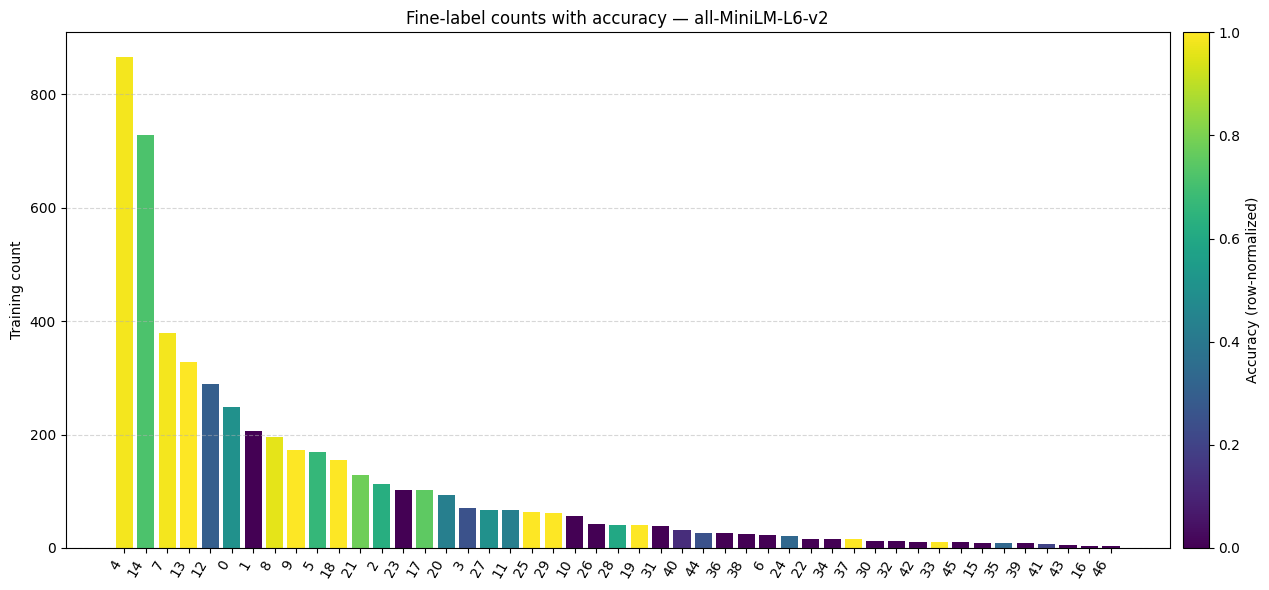

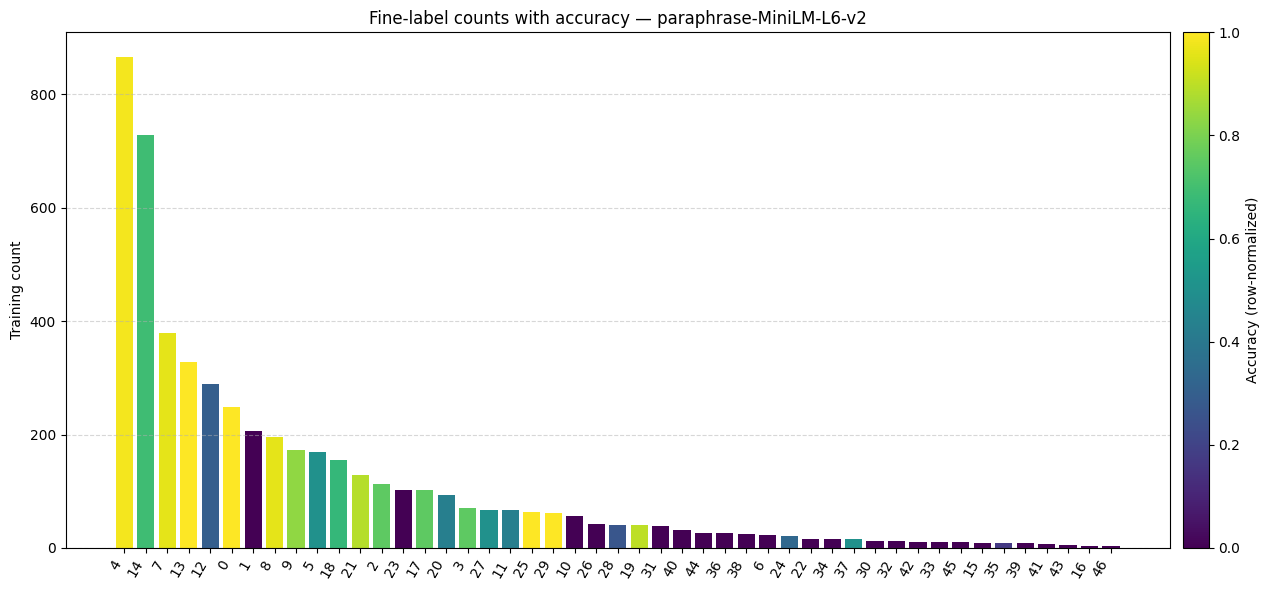

In [47]:
# Bar chart for all fine-label counts with accuracy annotations
train_counts = train_split_df["label-fine"].value_counts().sort_values(ascending=False)

labels = train_counts.index.tolist()
counts = train_counts.values.tolist()

artifacts_source = artifacts_augmented if "artifacts_augmented" in globals() else artifacts

for model_name in embedding_models:
    y_true_labels = np.asarray(y_test_labels)
    test_pred_idx = artifacts_source[model_name]["test_pred_idx"]
    y_pred_labels = np.take(class_names, test_pred_idx)

    cm_full = confusion_matrix(
        y_true_labels,
        y_pred_labels,
        labels=class_names,
        normalize="true",
    )

    acc_values = np.array([cm_full[class_to_idx[label], class_to_idx[label]] for label in labels])

    fig, ax = plt.subplots(figsize=(14, 6))
    x = np.arange(len(labels))

    cmap = plt.cm.viridis
    norm = plt.Normalize(vmin=0, vmax=1)
    colors = cmap(norm(acc_values))

    ax.bar(x, counts, color=colors)

    ax.set_xticks(x)
    ax.set_xticklabels([str(label) for label in labels], rotation=60, ha="right")
    ax.set_ylabel("Training count")
    ax.set_title(f"Fine-label counts with accuracy — {model_name}")
    ax.grid(axis="y", linestyle="--", alpha=0.5)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, pad=0.01)
    cbar.set_label("Accuracy (row-normalized)")

    fig.tight_layout()
    plt.show()


In [ ]:
# Learning rate vs epoch accuracy grids (per model)
lr_values = [4,5,6,7,8]
epoch_values = [10000, 20000, 30000]

# Note: this trains len(lr_values) * len(epoch_values) models per embedding model.
def compute_accuracy_grid_for_model(
    model_name,
    X_train_text,
    X_test_text,
    y_train_labels,
    y_test_labels,
    class_to_idx,
    class_names,
    lr_values,
    epoch_values,
):
    X_train_emb = embed_texts(model_name, X_train_text)
    X_test_emb = embed_texts(model_name, X_test_text)

    X_train_tensor, Y_train_onehot_tensor, _ = make_multiclass_tensors(
        X_train_emb,
        y_train_labels,
        class_to_idx,
    )
    X_test_tensor, _, y_test_idx = make_multiclass_tensors(
        X_test_emb,
        y_test_labels,
        class_to_idx,
    )

    input_dim = X_train_tensor.shape[1]
    output_dim = Y_train_onehot_tensor.shape[1]

    acc_grid = np.zeros((len(lr_values), len(epoch_values)), dtype=float)

    for i, lr in enumerate(lr_values):
        for j, epochs in enumerate(epoch_values):
            model = build_linear_multiclass_model(input_dim, output_dim)
            trained_model, _ = model_fit_pytorch(
                X_train_tensor,
                Y_train_onehot_tensor,
                model,
                epochs=epochs,
                lr=lr,
            )
            _, pred_idx = pytorch_model_multiclass_inference(trained_model, X_test_tensor)
            acc_grid[i, j] = accuracy_score(y_test_idx, pred_idx)

    return acc_grid


def plot_accuracy_grid_table(acc_grid, lr_values, epoch_values, title, save_path=None):
    epoch_labels = [f"{e // 1000}k" for e in epoch_values]
    cell_text = [["lr/epochs"] + epoch_labels]
    for lr, row in zip(lr_values, acc_grid):
        cell_text.append([f"{lr:.1f}"] + [f"{acc:.2f}" for acc in row])

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.axis("off")
    table = ax.table(cellText=cell_text, cellLoc="center", loc="center")
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.4)
    ax.set_title(title)
    fig.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=200, bbox_inches="tight")

    plt.show()


for model_name in embedding_models:
    acc_grid = compute_accuracy_grid_for_model(
        model_name,
        X_train_text,
        X_test_text,
        y_train_labels,
        y_test_labels,
        class_to_idx,
        class_names,
        lr_values,
        epoch_values,
    )

    plot_accuracy_grid_table(
        acc_grid,
        lr_values,
        epoch_values,
        title=f"Accuracy grid — {model_name}",
        save_path=Path("new_matrices") / f"lr_epoch_accuracy_{model_name}.png",
    )
